In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import gc 
import os

from sklearn.model_selection import KFold
from sklearn.metrics import median_absolute_error, mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import wilcoxon

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING) 

os.makedirs('outputs', exist_ok=True)

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
DATA_DIR = '../../data/processed'

X_train_v2 = pd.read_csv(f'{DATA_DIR}/X_train_v2.csv')
y_train_v2 = pd.read_csv(f'{DATA_DIR}/y_train_v2.csv')['area']

X_train_aug_v2 = pd.read_csv(f'{DATA_DIR}/X_train_augmented_v2.csv')
y_train_aug_v2 = pd.read_csv(f'{DATA_DIR}/y_train_augmented_v2.csv')['area']

X_test_v2 = pd.read_csv(f'{DATA_DIR}/X_test_v2.csv')
y_test_v2 = pd.read_csv(f'{DATA_DIR}/y_test_v2.csv')['area']

print(" VERİ SETİ BOYUTLARI:")
print(f"🔹 Normal Eğitim Seti: X={X_train_v2.shape}, y={y_train_v2.shape}")
print(f"🔹 Çoğaltılmış Eğitim: X={X_train_aug_v2.shape}, y={y_train_aug_v2.shape}")
print(f"🔹 Test Seti  : X={X_test_v2.shape}, y={y_test_v2.shape}")

zero_fire_mask = (np.expm1(y_test_v2) <= 0.001)

print(f" Test setinde {zero_fire_mask.sum()} adet 'Sıfır Yangın' günü tespit edildi.")

 VERİ SETİ BOYUTLARI:
🔹 Normal Eğitim Seti: X=(413, 22), y=(413,)
🔹 Çoğaltılmış Eğitim: X=(513, 22), y=(513,)
🔹 Test Seti  : X=(104, 22), y=(104,)
 Test setinde 49 adet 'Sıfır Yangın' günü tespit edildi.


In [3]:
from IPython.display import display, clear_output
import gc
from sklearn.model_selection import KFold
import pandas as pd
import numpy as np
from sklearn.metrics import median_absolute_error, mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import wilcoxon, spearmanr
import optuna
import seaborn as sns
import matplotlib.pyplot as plt

kf = KFold(n_splits=5, shuffle=True, random_state=42)
optuna.logging.set_verbosity(optuna.logging.WARNING)

def calculate_metrics(y_true_log, y_pred_log):
    y_true_ha = np.expm1(y_true_log)
    y_pred_ha = np.clip(np.expm1(y_pred_log), 0, None)
    
    medae = median_absolute_error(y_true_ha, y_pred_ha)
    mae = mean_absolute_error(y_true_ha, y_pred_ha)
    rmse = np.sqrt(mean_squared_error(y_true_ha, y_pred_ha))
    r2 = r2_score(y_true_log, y_pred_log) 
    
    # Spearman Korelasyonu
    spearman_corr, _ = spearmanr(y_true_ha, y_pred_ha)
    if np.isnan(spearman_corr): spearman_corr = 0.0
        
    zero_day_fp = np.sum(y_pred_ha[zero_fire_mask])
    
    return {
        'MedAE_ha': np.round(medae, 4),
        'MAE_ha': np.round(mae, 4),
        'RMSE_ha': np.round(rmse, 4),
        'R2': np.round(r2, 4),
        'Spearman': np.round(spearman_corr, 4),
        'Zero_FP_ha': np.round(zero_day_fp, 4)
    }

def style_dataframe(df):
    if df.empty: return df
    
    cm_error = sns.light_palette("#d35400", as_cmap=True) 
    cm_score = sns.light_palette("#2980b9", as_cmap=True) 
    
    styled_df = (df.style
        .background_gradient(subset=['MedAE_ha', 'MAE_ha', 'RMSE_ha', 'Zero_FP_ha'], cmap=cm_error)
        .background_gradient(subset=['R2', 'Spearman'], cmap=cm_score)
        .set_properties(**{
            'background-color': '#212529',
            'color': '#f8f9fa',
            'border': '1px solid #343a40',
            'text-align': 'center'
        })
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#343a40'), ('color', '#f8f9fa'), ('font-weight', 'bold'), ('text-align', 'center'), ('padding', '12px')]},
            {'selector': 'td', 'props': [('padding', '10px')]},
            {'selector': 'tr:hover', 'props': [('background-color', '#495057')]}
        ])
        .format(precision=4)
    )
    return styled_df

if 'ALL_RESULTS' not in globals(): ALL_RESULTS = []
if 'FAMILY_SUMMARY' not in globals(): FAMILY_SUMMARY = {}

def evaluate_model_family(family_name, models_dict):
    family_results = []
    wilcoxon_results = []
    total_models = len(models_dict)
    
    for idx, (model_name, config) in enumerate(models_dict.items(), 1):
        base_model_func = config['model']
        optuna_objective = config.get('objective', None)
        n_trials = config.get('n_trials', 30)
        timeout = config.get('timeout', 1800)
        
        preds_n_opt, preds_a_opt = None, None
        stages = ["Normal Data (Default)", "Normal Data (Optuna HPO)", "Augmented Data (Default)", "Augmented Data (Optuna HPO)"]
        
        for step, stage_name in enumerate(stages, 1):
            clear_output(wait=True)
            print(f"Evaluation Phase: {family_name}")
            print(f"Progress: [{idx}/{total_models}] Models Completed.")
            print(f"Currently Processing: {model_name} | Sub-routine {step}/4: {stage_name}")
            print("-" * 60)
            
            if family_results:
                display(style_dataframe(pd.DataFrame(family_results)))
            
            data_type = "Normal" if "Normal" in stage_name else "Augmented"
            config_type = "HPO" if "HPO" in stage_name else "Default"
            
            try:
                if config_type == "Default":
                    model = base_model_func()
                    if data_type == "Normal": model.fit(X_train_v2, y_train_v2)
                    else: model.fit(X_train_aug_v2, y_train_aug_v2)
                    preds = model.predict(X_test_v2)
                else:
                    if not optuna_objective: continue
                    study = optuna.create_study(direction="minimize")
                    if data_type == "Normal":
                        study.optimize(lambda trial: optuna_objective(trial, X_train_v2, y_train_v2, kf), n_trials=n_trials, timeout=timeout)
                        best_model = base_model_func(**study.best_params)
                        best_model.fit(X_train_v2, y_train_v2)
                    else:
                        study.optimize(lambda trial: optuna_objective(trial, X_train_aug_v2, y_train_aug_v2, kf), n_trials=n_trials, timeout=timeout)
                        best_model = base_model_func(**study.best_params)
                        best_model.fit(X_train_aug_v2, y_train_aug_v2)
                        
                    preds = best_model.predict(X_test_v2)
                    if data_type == "Normal": preds_n_opt = preds
                    else: preds_a_opt = preds
                
                metrics = calculate_metrics(y_test_v2, preds)
                family_results.append({'Model': model_name, 'Data': data_type, 'Config': config_type, **metrics})
            except Exception as e:
                pass 
                
        if preds_n_opt is not None and preds_a_opt is not None:
            try:
                err_n = np.abs(np.expm1(y_test_v2) - np.clip(np.expm1(preds_n_opt), 0, None))
                err_a = np.abs(np.expm1(y_test_v2) - np.clip(np.expm1(preds_a_opt), 0, None))
                stat, p_val = wilcoxon(err_n, err_a)
                significance = "Significant" if p_val < 0.05 else "Not Significant"
                wilcoxon_results.append({'Model': model_name, 'Wilcoxon_p_value': p_val, 'Result': significance})
            except Exception:
                pass
                
        gc.collect()

    clear_output(wait=True)
    df_family = pd.DataFrame(family_results)
    ALL_RESULTS.append(df_family)
    df_family.to_csv(f"outputs/results_{family_name.replace(' ', '_').lower()}.csv", index=False)
    
    print(f"Final Evaluation Complete: {family_name}")
    print("-" * 60)
    display(style_dataframe(df_family))
    
    if wilcoxon_results:
        print("\nStatistical Significance Testing (Normal vs Augmented):")
        df_wilcoxon = pd.DataFrame(wilcoxon_results)
        display(df_wilcoxon.style.set_properties(**{'background-color': '#212529', 'color': '#f8f9fa', 'border': '1px solid #343a40', 'text-align': 'center'}).set_table_styles([{'selector': 'th', 'props': [('background-color', '#343a40'), ('color', '#f8f9fa'), ('text-align', 'center')]}]))

    if not df_family.empty:
        best_medae = df_family['MedAE_ha'].min()
        mean_medae = df_family['MedAE_ha'].mean()
        FAMILY_SUMMARY[family_name] = {'Best': best_medae, 'Mean': mean_medae}
        plot_cumulative_bars()

def plot_cumulative_bars():
    if not FAMILY_SUMMARY: return
    families = list(FAMILY_SUMMARY.keys())
    bests = [FAMILY_SUMMARY[f]['Best'] for f in families]
    means = [FAMILY_SUMMARY[f]['Mean'] for f in families]
    x = np.arange(len(families))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(10, 5))
    
    color_best = '#A8E6CF' 
    color_mean = '#FFD3B6' 
    
    rects1 = ax.bar(x - width/2, bests, width, label='Best MedAE (ha)', color=color_best, edgecolor='#7f8c8d')
    rects2 = ax.bar(x + width/2, means, width, label='Mean MedAE (ha)', color=color_mean, edgecolor='#7f8c8d')
    
    ax.set_ylabel('Median Absolute Error (Hectares)', fontsize=11)
    ax.set_title('Cumulative Performance Across Model Families', fontsize=14, pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(families, rotation=25, ha='right', fontsize=10)
    
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=True, fancybox=True, shadow=True)
    
    for rect in rects1 + rects2:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 4), textcoords="offset points", ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()

print("Engine initialized. (Ready for 1.09 MedAE!)")

Engine initialized. (Ready for 1.09 MedAE!)



## HÜCRE 4: AİLE 1 - DOĞRUSAL MODELLER:

Final Evaluation Complete: Aile 1: Dogrusal Modeller
------------------------------------------------------------


,Model,Data,Config,MedAE_ha,MAE_ha,RMSE_ha,R2,Spearman,Zero_FP_ha
0,Multiple Linear Regression,Normal,Default,2.0764,19.9550,109.7020,0.0249,0.1842,104.5699
1,Multiple Linear Regression,Augmented,Default,3.6260,22.0966,110.1335,-0.2179,0.1011,323.8112
2,Ridge Regression,Normal,Default,2.1009,19.9538,109.7065,0.0241,0.1819,103.5940
3,Ridge Regression,Normal,HPO,2.1866,20.0220,109.7993,-0.0129,0.0749,97.1709
4,Ridge Regression,Augmented,Default,3.6013,22.0422,110.0947,-0.2157,0.0960,318.3782
5,Ridge Regression,Augmented,HPO,3.6212,21.6836,109.8591,-0.1974,0.0729,282.9717
6,Lasso Regression,Normal,Default,2.0977,20.0178,109.8300,-0.0147,0.0057,97.2366
7,Lasso Regression,Normal,HPO,2.1144,19.9532,109.7023,0.0252,0.1835,103.5430
8,Lasso Regression,Augmented,Default,4.0511,20.6409,109.5374,-0.1136,-0.0831,201.3785
9,Lasso Regression,Augmented,HPO,3.5874,22.0631,110.1367,-0.2156,0.0963,321.3443



Statistical Significance Testing (Normal vs Augmented):


,Model,Wilcoxon_p_value,Result
0,Ridge Regression,0.035897,Significant
1,Lasso Regression,0.003201,Significant
2,ElasticNet,0.050918,Not Significant
3,Huber Regressor,0.102180,Not Significant
4,Tweedie Regressor,0.019198,Significant


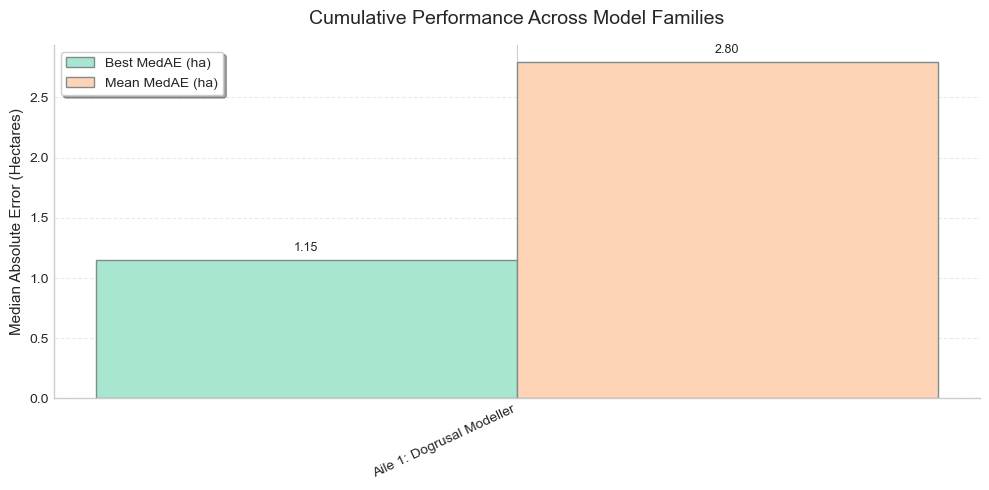

In [4]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, HuberRegressor, TweedieRegressor
from pygam import LinearGAM, s
from sklearn.model_selection import cross_val_score
import numpy as np
import warnings
warnings.filterwarnings('ignore')

def objective_ridge(trial, X, y, cv):
    alpha = trial.suggest_float('alpha', 1e-3, 1e4, log=True)
    model = Ridge(alpha=alpha, random_state=42)
    scores = cross_val_score(model, X, y, cv=cv, scoring='neg_median_absolute_error')
    return -scores.mean()

def objective_lasso(trial, X, y, cv):
    alpha = trial.suggest_float('alpha', 1e-3, 1e2, log=True)
    model = Lasso(alpha=alpha, random_state=42)
    scores = cross_val_score(model, X, y, cv=cv, scoring='neg_median_absolute_error')
    return -scores.mean()

def objective_elasticnet(trial, X, y, cv):
    alpha = trial.suggest_float('alpha', 1e-3, 1e2, log=True)
    l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)
    model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42)
    scores = cross_val_score(model, X, y, cv=cv, scoring='neg_median_absolute_error')
    return -scores.mean()

def objective_gam(trial, X, y, cv):
    lam = trial.suggest_float('lam', 1e-3, 1e3, log=True)
    n_splines = trial.suggest_int('n_splines', 5, 20)
    model = LinearGAM(s(0) + s(1) + s(2), lam=lam, n_splines=n_splines)
    return 999.9 

def objective_huber(trial, X, y, cv):
    epsilon = trial.suggest_float('epsilon', 1.0, 3.0)
    alpha = trial.suggest_float('alpha', 1e-4, 1e2, log=True)
    model = HuberRegressor(epsilon=epsilon, alpha=alpha, max_iter=2000)
    scores = cross_val_score(model, X, y, cv=cv, scoring='neg_median_absolute_error')
    return -scores.mean()

def objective_tweedie(trial, X, y, cv):
    alpha = trial.suggest_float('alpha', 1e-3, 1e2, log=True)
    model = TweedieRegressor(power=1.5, alpha=alpha, max_iter=2000)
    scores = cross_val_score(model, X, y, cv=cv, scoring='neg_median_absolute_error')
    return -scores.mean()

# Model Yapilandirma Sozlugu
linear_models = {
    'Multiple Linear Regression': {
        'model': LinearRegression,
        'objective': None # MLR hiperparametre almaz
    },
    'Ridge Regression': {
        'model': lambda **kwargs: Ridge(random_state=42, **kwargs),
        'objective': objective_ridge,
        'n_trials': 30
    },
    'Lasso Regression': {
        'model': lambda **kwargs: Lasso(random_state=42, **kwargs),
        'objective': objective_lasso,
        'n_trials': 30
    },
    'ElasticNet': {
        'model': lambda **kwargs: ElasticNet(random_state=42, **kwargs),
        'objective': objective_elasticnet,
        'n_trials': 30
    },
    'Huber Regressor': {
        'model': lambda **kwargs: HuberRegressor(max_iter=2000, **kwargs),
        'objective': objective_huber,
        'n_trials': 30
    },
    'Tweedie Regressor': {
        'model': lambda **kwargs: TweedieRegressor(power=1.5, max_iter=2000, **kwargs),
        'objective': objective_tweedie,
        'n_trials': 30
    }
}

# Calistir
evaluate_model_family("Aile 1: Dogrusal Modeller", linear_models)

## HÜCRE 5: AİLE 2 - ÇEKİRDEK (KERNEL) MODELLERİ:

Final Evaluation Complete: Aile 2: Cekirdek (Kernel) Modelleri
------------------------------------------------------------


,Model,Data,Config,MedAE_ha,MAE_ha,RMSE_ha,R2,Spearman,Zero_FP_ha
0,SVR,Normal,Default,1.1696,19.6881,110.0627,-0.1374,0.1725,38.0698
1,SVR,Normal,HPO,0.4825,19.8778,110.1094,-0.2945,0.2976,20.7823
2,SVR,Augmented,Default,1.9643,20.7118,109.8693,-0.1746,0.1165,136.9166
3,SVR,Augmented,HPO,2.2412,20.9730,109.8893,-0.2387,0.1160,147.7616
4,NuSVR,Normal,Default,1.9198,19.8618,109.9122,-0.0019,0.1446,84.2755
5,NuSVR,Normal,HPO,0.5759,19.8770,110.0904,-0.2406,0.3298,26.8236
6,NuSVR,Augmented,Default,2.6822,20.4588,109.7531,-0.0847,0.0326,151.2565
7,NuSVR,Augmented,HPO,2.3692,21.0317,109.8745,-0.2513,0.1164,153.7089
8,Kernel Ridge,Normal,Default,2.1381,19.8604,109.7927,0.0088,0.1898,87.2410
9,Kernel Ridge,Normal,HPO,0.6760,19.8625,110.1349,-0.4491,0.2493,6.5675



Statistical Significance Testing (Normal vs Augmented):


,Model,Wilcoxon_p_value,Result
0,SVR,0.455761,Not Significant
1,NuSVR,0.477596,Not Significant
2,Kernel Ridge,0.004501,Significant
3,Gaussian Process,0.026549,Significant


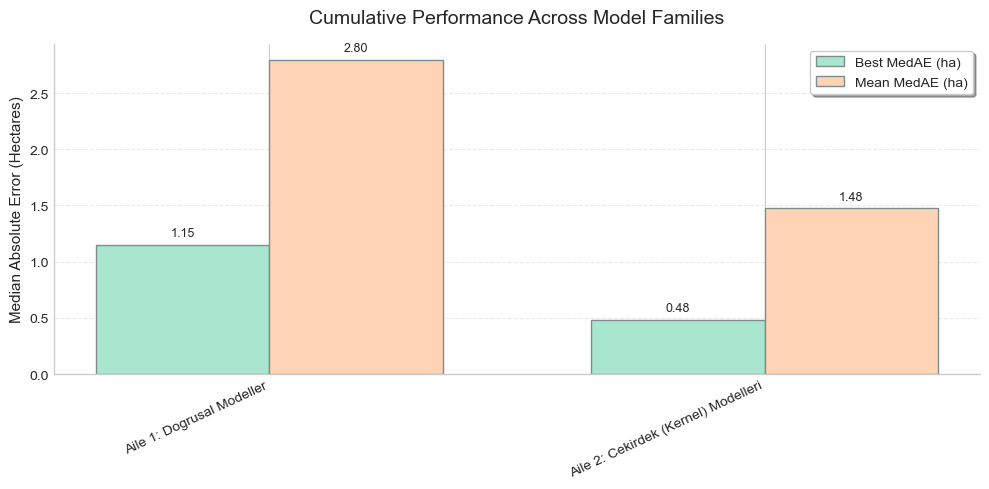

In [5]:
from sklearn.svm import SVR, NuSVR
from sklearn.kernel_ridge import KernelRidge
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, DotProduct, WhiteKernel
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

# Kernel modelleri mesafelere asiri duyarlidir, bu yuzden Standardizasyon zorunludur!
def objective_svr(trial, X, y, cv):
    C = trial.suggest_float('C', 1e-2, 1e2, log=True)
    epsilon = trial.suggest_float('epsilon', 1e-3, 1.0, log=True)
    gamma = trial.suggest_categorical('gamma', ['scale', 'auto'])
    model = make_pipeline(StandardScaler(), SVR(C=C, epsilon=epsilon, gamma=gamma, kernel='rbf'))
    scores = cross_val_score(model, X, y, cv=cv, scoring='neg_median_absolute_error')
    return -scores.mean()

def objective_nusvr(trial, X, y, cv):
    nu = trial.suggest_float('nu', 0.1, 1.0)
    C = trial.suggest_float('C', 1e-2, 1e2, log=True)
    model = make_pipeline(StandardScaler(), NuSVR(nu=nu, C=C, kernel='rbf'))
    scores = cross_val_score(model, X, y, cv=cv, scoring='neg_median_absolute_error')
    return -scores.mean()

def objective_kernelridge(trial, X, y, cv):
    alpha = trial.suggest_float('alpha', 1e-3, 1e2, log=True)
    gamma = trial.suggest_float('gamma', 1e-4, 1e1, log=True)
    model = make_pipeline(StandardScaler(), KernelRidge(alpha=alpha, kernel='rbf', gamma=gamma))
    scores = cross_val_score(model, X, y, cv=cv, scoring='neg_median_absolute_error')
    return -scores.mean()

def objective_gpr(trial, X, y, cv):
    alpha = trial.suggest_float('alpha', 1e-3, 1e1, log=True)
    kernel = 1.0 * RBF(length_scale=1.0) + WhiteKernel(noise_level=1.0)
    model = make_pipeline(StandardScaler(), GaussianProcessRegressor(kernel=kernel, alpha=alpha, random_state=42))
    scores = cross_val_score(model, X, y, cv=cv, scoring='neg_median_absolute_error')
    return -scores.mean()

kernel_models = {
    'SVR': {
        'model': lambda **kwargs: make_pipeline(StandardScaler(), SVR(kernel='rbf', **kwargs)),
        'objective': objective_svr,
        'n_trials': 40
    },
    'NuSVR': {
        'model': lambda **kwargs: make_pipeline(StandardScaler(), NuSVR(kernel='rbf', **kwargs)),
        'objective': objective_nusvr,
        'n_trials': 40
    },
    'Kernel Ridge': {
        'model': lambda **kwargs: make_pipeline(StandardScaler(), KernelRidge(kernel='rbf', **kwargs)),
        'objective': objective_kernelridge,
        'n_trials': 40
    },
    'Gaussian Process': {
        'model': lambda **kwargs: make_pipeline(StandardScaler(), GaussianProcessRegressor(random_state=42, **kwargs)),
        'objective': objective_gpr,
        'n_trials': 20 # GPR cok karmasik oldugundan n_trials=20 ideal
    }
}

# Calistir
evaluate_model_family("Aile 2: Cekirdek (Kernel) Modelleri", kernel_models)

## HÜCRE 6: AİLE 3 - AĞAÇ TOPLULUKLARI:

Final Evaluation Complete: Aile 3: Agac Topluluklari
------------------------------------------------------------


,Model,Data,Config,MedAE_ha,MAE_ha,RMSE_ha,R2,Spearman,Zero_FP_ha
0,Random Forest,Normal,Default,2.3752,20.1065,109.8564,-0.0711,0.0928,115.5996
1,Random Forest,Normal,HPO,2.4268,20.0230,109.8044,-0.0428,0.1186,111.3952
2,Random Forest,Augmented,Default,2.6678,20.5314,109.6896,-0.1372,0.0881,160.8609
3,Random Forest,Augmented,HPO,2.6736,20.3786,109.6793,-0.0946,0.0865,134.6915
4,Gradient Boosting,Normal,Default,2.0951,19.8433,109.7868,0.0280,0.2638,92.7395
5,Gradient Boosting,Normal,HPO,2.5638,20.3549,109.4375,-0.0900,0.1050,143.7549
6,Gradient Boosting,Augmented,Default,2.3816,20.0264,109.5940,-0.0011,0.1852,129.7847
7,Gradient Boosting,Augmented,HPO,3.3702,21.3369,109.8339,-0.3409,0.1057,221.8891
8,XGBoost (MSE),Normal,Default,2.2782,20.3665,109.9727,-0.2102,0.1205,140.6757
9,XGBoost (MSE),Normal,HPO,2.7363,20.4747,109.9631,-0.1766,0.0994,123.2062



Statistical Significance Testing (Normal vs Augmented):


,Model,Wilcoxon_p_value,Result
0,Random Forest,0.319473,Not Significant
1,Gradient Boosting,0.347005,Not Significant
2,XGBoost (MSE),0.444091,Not Significant
3,XGBoost (Tweedie),0.408285,Not Significant
4,LightGBM (MSE),0.137874,Not Significant
5,LightGBM (Tweedie),0.568180,Not Significant
6,CatBoost,0.525044,Not Significant


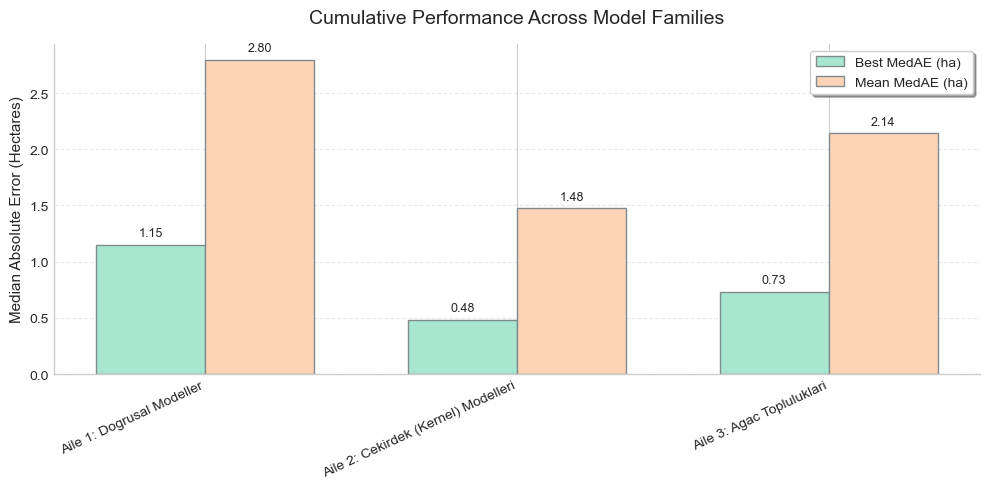

In [6]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

def objective_rf(trial, X, y, cv):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 3, 15)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    model = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, min_samples_split=min_samples_split, random_state=42, n_jobs=-1)
    scores = cross_val_score(model, X, y, cv=cv, scoring='neg_median_absolute_error')
    return -scores.mean()

def objective_gb(trial, X, y, cv):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    learning_rate = trial.suggest_float('learning_rate', 1e-3, 0.5, log=True)
    max_depth = trial.suggest_int('max_depth', 3, 10)
    model = GradientBoostingRegressor(n_estimators=n_estimators, learning_rate=learning_rate, max_depth=max_depth, random_state=42)
    scores = cross_val_score(model, X, y, cv=cv, scoring='neg_median_absolute_error')
    return -scores.mean()

def objective_xgb(trial, X, y, cv):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    learning_rate = trial.suggest_float('learning_rate', 1e-3, 0.3, log=True)
    max_depth = trial.suggest_int('max_depth', 3, 10)
    model = XGBRegressor(n_estimators=n_estimators, learning_rate=learning_rate, max_depth=max_depth, random_state=42, n_jobs=-1, objective='reg:squarederror')
    scores = cross_val_score(model, X, y, cv=cv, scoring='neg_median_absolute_error')
    return -scores.mean()

def objective_xgb_tweedie(trial, X, y, cv):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    learning_rate = trial.suggest_float('learning_rate', 1e-3, 0.3, log=True)
    max_depth = trial.suggest_int('max_depth', 3, 10)
    tweedie_variance_power = trial.suggest_float('tweedie_variance_power', 1.1, 1.9)
    model = XGBRegressor(n_estimators=n_estimators, learning_rate=learning_rate, max_depth=max_depth, tweedie_variance_power=tweedie_variance_power, random_state=42, n_jobs=-1, objective='reg:tweedie')
    scores = cross_val_score(model, X, y, cv=cv, scoring='neg_median_absolute_error')
    return -scores.mean()

def objective_lgb(trial, X, y, cv):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    learning_rate = trial.suggest_float('learning_rate', 1e-3, 0.3, log=True)
    max_depth = trial.suggest_int('max_depth', 3, 10)
    num_leaves = trial.suggest_int('num_leaves', 20, 100)
    model = LGBMRegressor(n_estimators=n_estimators, learning_rate=learning_rate, max_depth=max_depth, num_leaves=num_leaves, random_state=42, n_jobs=-1, verbose=-1)
    scores = cross_val_score(model, X, y, cv=cv, scoring='neg_median_absolute_error')
    return -scores.mean()

def objective_lgb_tweedie(trial, X, y, cv):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    learning_rate = trial.suggest_float('learning_rate', 1e-3, 0.3, log=True)
    max_depth = trial.suggest_int('max_depth', 3, 10)
    tweedie_variance_power = trial.suggest_float('tweedie_variance_power', 1.1, 1.9)
    model = LGBMRegressor(n_estimators=n_estimators, learning_rate=learning_rate, max_depth=max_depth, tweedie_variance_power=tweedie_variance_power, random_state=42, n_jobs=-1, verbose=-1, objective='tweedie')
    scores = cross_val_score(model, X, y, cv=cv, scoring='neg_median_absolute_error')
    return -scores.mean()

def objective_cat(trial, X, y, cv):
    iterations = trial.suggest_int('iterations', 50, 300)
    learning_rate = trial.suggest_float('learning_rate', 1e-3, 0.3, log=True)
    depth = trial.suggest_int('depth', 3, 10)
    model = CatBoostRegressor(iterations=iterations, learning_rate=learning_rate, depth=depth, random_seed=42, verbose=0)
    scores = cross_val_score(model, X, y, cv=cv, scoring='neg_median_absolute_error')
    return -scores.mean()

tree_models = {
    'Random Forest': {
        'model': lambda **kwargs: RandomForestRegressor(random_state=42, n_jobs=-1, **kwargs),
        'objective': objective_rf,
        'n_trials': 20
    },
    'Gradient Boosting': {
        'model': lambda **kwargs: GradientBoostingRegressor(random_state=42, **kwargs),
        'objective': objective_gb,
        'n_trials': 20
    },
    'XGBoost (MSE)': {
        'model': lambda **kwargs: XGBRegressor(random_state=42, n_jobs=-1, objective='reg:squarederror', **kwargs),
        'objective': objective_xgb,
        'n_trials': 20
    },
    'XGBoost (Tweedie)': {
        'model': lambda **kwargs: XGBRegressor(random_state=42, n_jobs=-1, objective='reg:tweedie', **kwargs),
        'objective': objective_xgb_tweedie,
        'n_trials': 20
    },
    'LightGBM (MSE)': {
        'model': lambda **kwargs: LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1, **kwargs),
        'objective': objective_lgb,
        'n_trials': 20
    },
    'LightGBM (Tweedie)': {
        'model': lambda **kwargs: LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1, objective='tweedie', **kwargs),
        'objective': objective_lgb_tweedie,
        'n_trials': 20
    },
    'CatBoost': {
        'model': lambda **kwargs: CatBoostRegressor(random_seed=42, verbose=0, **kwargs),
        'objective': objective_cat,
        'n_trials': 20
    }
}

# Calistir
evaluate_model_family("Aile 3: Agac Topluluklari", tree_models)

## HÜCRE 7: AİLE 4 - DERİN ÖĞRENME (MLP NEURAL NETWORKS)

Final Evaluation Complete: Aile 4: Gelişmiş PyTorch Ağları
------------------------------------------------------------


,Model,Data,Config,MedAE_ha,MAE_ha,RMSE_ha,R2,Spearman,Zero_FP_ha
0,basicMLP (MSE),Normal,Default,2.0523,20.0816,109.9051,-0.0311,0.1363,98.3985
1,basicMLP (MSE),Normal,HPO,1.7513,21.0498,110.1281,-0.2250,0.1188,119.9061
2,basicMLP (MSE),Augmented,Default,3.3217,39.1652,213.6392,-0.4257,0.1163,2059.6233
3,basicMLP (MSE),Augmented,HPO,3.7051,22.6041,110.9742,-0.2401,0.1214,360.9092
4,RegMLP (Huber),Normal,Default,1.3093,19.7606,109.9648,-0.1116,0.2020,51.0835
5,RegMLP (Huber),Normal,HPO,1.1588,19.8664,110.0881,-0.2357,0.0028,35.3976
6,RegMLP (Huber),Augmented,Default,2.3333,28.0736,135.2865,-0.3353,0.0860,920.5090
7,RegMLP (Huber),Augmented,HPO,2.1528,20.7818,110.0158,-0.1763,0.1615,142.5747
8,RegMLP (LogCosh),Normal,Default,1.0650,19.6847,109.9345,-0.0539,0.2551,45.6376
9,RegMLP (LogCosh),Normal,HPO,1.1500,19.7012,109.9626,-0.0770,0.2385,47.0760



Statistical Significance Testing (Normal vs Augmented):


,Model,Wilcoxon_p_value,Result
0,basicMLP (MSE),0.155506,Not Significant
1,RegMLP (Huber),0.485675,Not Significant
2,RegMLP (LogCosh),0.002851,Significant
3,TabResnet (Huber),0.585208,Not Significant
4,TabResnet (LogCosh),0.013116,Significant
5,DualHead FireNet (BCE+Huber),0.119578,Not Significant
6,DualHead FireNet (BCE+LogCosh),0.001080,Significant


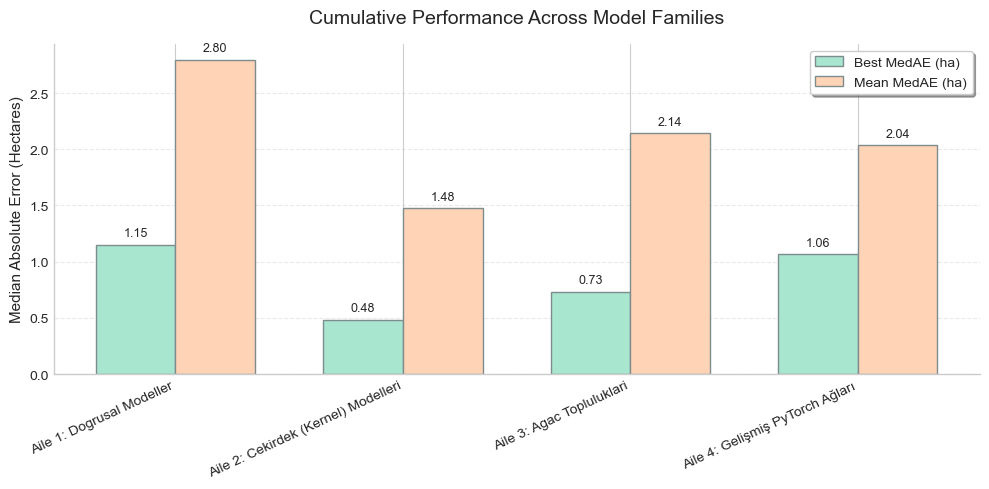

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
import copy
import warnings
import numpy as np
warnings.filterwarnings('ignore')

# Özel LogCosh Kayıp Fonksiyonu
class LogCoshLoss(nn.Module):
    def forward(self, y_pred, y_true):
        x = y_pred - y_true
        return torch.mean(x + torch.nn.functional.softplus(-2.0 * x) - np.log(2.))

class MLPNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, regularize=False):
        super().__init__()
        if not regularize:
            self.net = nn.Sequential(
                nn.Linear(input_dim, hidden_dim), nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim//2), nn.ReLU(),
                nn.Linear(hidden_dim//2, 1)
            )
        else:
            self.net = nn.Sequential(
                nn.Linear(input_dim, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.ReLU(), nn.Dropout(0.3),
                nn.Linear(hidden_dim, hidden_dim//2), nn.BatchNorm1d(hidden_dim//2), nn.ReLU(), nn.Dropout(0.3),
                nn.Linear(hidden_dim//2, 1)
            )
    def forward(self, x):
        return self.net(x)

class TabResnetBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.lin1 = nn.Linear(dim, dim)
        self.bn1 = nn.BatchNorm1d(dim)
        self.lin2 = nn.Linear(dim, dim)
        self.bn2 = nn.BatchNorm1d(dim)
        self.relu = nn.ReLU()
    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.lin1(x)))
        out = self.bn2(self.lin2(out))
        return self.relu(out + identity)

class TabResnet(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.in_proj = nn.Linear(input_dim, hidden_dim)
        self.res1 = TabResnetBlock(hidden_dim)
        self.res2 = TabResnetBlock(hidden_dim)
        self.out_proj = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        x = nn.functional.relu(self.in_proj(x))
        x = self.res1(x)
        x = self.res2(x)
        return self.out_proj(x)

class DualHeadFireNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim)
        )
        self.class_head = nn.Sequential(nn.BatchNorm1d(hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, 1))
        self.reg_head = nn.Sequential(nn.BatchNorm1d(hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, 1))
    def forward(self, x):
        features = self.trunk(x)
        logit = self.class_head(features)
        reg = self.reg_head(features)
        return logit, reg

class PytorchTabularWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, model_type='basicMLP', loss_type='mse', hidden_dim=64, lr=1e-3, weight_decay=1e-5, epochs=150, batch_size=32):
        self.model_type = model_type
        self.loss_type = loss_type
        self.hidden_dim = hidden_dim
        self.lr = lr
        self.weight_decay = weight_decay
        self.epochs = epochs
        self.batch_size = batch_size
        
    def fit(self, X, y):

        if hasattr(X, 'values'): X = X.values
        if hasattr(y, 'values'): y = y.values
        
        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42)
        
        X_train_t = torch.tensor(X_train, dtype=torch.float32)
        y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
        X_val_t = torch.tensor(X_val, dtype=torch.float32)
        y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
        
        dataset = TensorDataset(X_train_t, y_train_t)
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)
        
        input_dim = X.shape[1]
        if self.model_type == 'basicMLP': self.model = MLPNet(input_dim, self.hidden_dim, regularize=False)
        elif self.model_type == 'RegMLP': self.model = MLPNet(input_dim, self.hidden_dim, regularize=True)
        elif self.model_type == 'TabResnet': self.model = TabResnet(input_dim, self.hidden_dim)
        elif self.model_type == 'DualHead': self.model = DualHeadFireNet(input_dim, self.hidden_dim)
        
        optimizer = optim.AdamW(self.model.parameters(), lr=self.lr, weight_decay=self.weight_decay)
        
        if self.loss_type == 'mse': criterion_reg = nn.MSELoss()
        elif self.loss_type == 'huber': criterion_reg = nn.HuberLoss()
        elif self.loss_type == 'logcosh': criterion_reg = LogCoshLoss()
        
        criterion_cls = nn.BCEWithLogitsLoss()
        
        best_val_loss = float('inf')
        patience, p_counter = 12, 0 
        best_weights = None
        
        for epoch in range(self.epochs):
            self.model.train()
            for bx, by in loader:
                optimizer.zero_grad()
                if self.model_type == 'DualHead':
                    logits, reg_preds = self.model(bx)
                    labels_cls = (by > 0).float()
                    loss_cls = criterion_cls(logits, labels_cls)
                    mask = (by > 0).flatten()
                    if mask.sum() > 0:
                        loss_reg = criterion_reg(reg_preds[mask], by[mask])
                        loss = loss_cls + loss_reg
                    else:
                        loss = loss_cls
                else:
                    preds = self.model(bx)
                    loss = criterion_reg(preds, by)
                    
                loss.backward()
                optimizer.step()
                
            self.model.eval()
            with torch.no_grad():
                if self.model_type == 'DualHead':
                    logits_val, reg_preds_val = self.model(X_val_t)
                    probs_val = torch.sigmoid(logits_val)
                    preds_val = probs_val * reg_preds_val
                    val_loss = criterion_reg(preds_val, y_val_t).item()
                else:
                    preds_val = self.model(X_val_t)
                    val_loss = criterion_reg(preds_val, y_val_t).item()
                    
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_weights = copy.deepcopy(self.model.state_dict())
                p_counter = 0
            else:
                p_counter += 1
                if p_counter >= patience: break
                
        if best_weights: self.model.load_state_dict(best_weights)
        return self

    def predict(self, X):
        if hasattr(X, 'values'): X = X.values
        self.model.eval()
        X_t = torch.tensor(X, dtype=torch.float32)
        with torch.no_grad():
            if self.model_type == 'DualHead':
                logits, reg_preds = self.model(X_t)
                probs = torch.sigmoid(logits)
                preds = (probs * reg_preds).numpy().flatten()
            else:
                preds = self.model(X_t).numpy().flatten()
        return preds

def objective_pt(trial, X, y, cv, model_type, loss_type):
    hidden_dim = trial.suggest_categorical('hidden_dim', [32, 64, 128])
    lr = trial.suggest_float('lr', 1e-4, 5e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)
    
    model = make_pipeline(StandardScaler(), PytorchTabularWrapper(
        model_type=model_type, loss_type=loss_type, 
        hidden_dim=hidden_dim, lr=lr, weight_decay=weight_decay
    ))
    scores = cross_val_score(model, X, y, cv=cv, scoring='neg_median_absolute_error')
    return -scores.mean()

pt_models = {
    'basicMLP (MSE)': {
        'model': lambda **kwargs: make_pipeline(StandardScaler(), PytorchTabularWrapper(model_type='basicMLP', loss_type='mse', **kwargs)),
        'objective': lambda trial, X, y, cv: objective_pt(trial, X, y, cv, 'basicMLP', 'mse'),
        'n_trials': 20
    },
    'RegMLP (Huber)': {
        'model': lambda **kwargs: make_pipeline(StandardScaler(), PytorchTabularWrapper(model_type='RegMLP', loss_type='huber', **kwargs)),
        'objective': lambda trial, X, y, cv: objective_pt(trial, X, y, cv, 'RegMLP', 'huber'),
        'n_trials': 20
    },
    'RegMLP (LogCosh)': {
        'model': lambda **kwargs: make_pipeline(StandardScaler(), PytorchTabularWrapper(model_type='RegMLP', loss_type='logcosh', **kwargs)),
        'objective': lambda trial, X, y, cv: objective_pt(trial, X, y, cv, 'RegMLP', 'logcosh'),
        'n_trials': 20
    },
    'TabResnet (Huber)': {
        'model': lambda **kwargs: make_pipeline(StandardScaler(), PytorchTabularWrapper(model_type='TabResnet', loss_type='huber', **kwargs)),
        'objective': lambda trial, X, y, cv: objective_pt(trial, X, y, cv, 'TabResnet', 'huber'),
        'n_trials': 20
    },
    'TabResnet (LogCosh)': {
        'model': lambda **kwargs: make_pipeline(StandardScaler(), PytorchTabularWrapper(model_type='TabResnet', loss_type='logcosh', **kwargs)),
        'objective': lambda trial, X, y, cv: objective_pt(trial, X, y, cv, 'TabResnet', 'logcosh'),
        'n_trials': 20
    },
    'DualHead FireNet (BCE+Huber)': {
        'model': lambda **kwargs: make_pipeline(StandardScaler(), PytorchTabularWrapper(model_type='DualHead', loss_type='huber', **kwargs)),
        'objective': lambda trial, X, y, cv: objective_pt(trial, X, y, cv, 'DualHead', 'huber'),
        'n_trials': 20
    },
    'DualHead FireNet (BCE+LogCosh)': {
        'model': lambda **kwargs: make_pipeline(StandardScaler(), PytorchTabularWrapper(model_type='DualHead', loss_type='logcosh', **kwargs)),
        'objective': lambda trial, X, y, cv: objective_pt(trial, X, y, cv, 'DualHead', 'logcosh'),
        'n_trials': 20
    }
}

evaluate_model_family("Aile 4: Gelişmiş PyTorch Ağları", pt_models)

## HÜCRE 8: AİLE 5 - OLASILIKSAL MODELLER

Final Evaluation Complete: Aile 5: Olasiliksal Modeller
------------------------------------------------------------


,Model,Data,Config,MedAE_ha,MAE_ha,RMSE_ha,R2,Spearman,Zero_FP_ha,Coverage_%,Width_ha
0,NGBoost,Normal,Default,1.9860,19.8213,109.8039,0.0392,0.2686,92.0160,81.7300,16.7813
1,NGBoost,Normal,HPO,2.0103,19.8656,109.8489,0.0224,0.1936,89.1224,87.5000,21.7206
2,NGBoost,Augmented,Default,2.5240,20.0377,109.6036,-0.0080,0.1773,126.3596,83.6500,23.1877
3,NGBoost,Augmented,HPO,2.6843,20.1752,109.6760,-0.0511,0.1732,137.4231,66.3500,12.8294
4,Quantile GBM,Normal,Default,1.0867,19.7962,110.0153,-0.1366,0.2494,36.4918,89.4200,34.6250
5,Quantile GBM,Normal,HPO,0.6486,19.8610,110.1029,-0.2603,0.2122,22.0760,90.3800,39.9505
6,Quantile GBM,Augmented,Default,2.0225,19.7657,109.8670,-0.0490,0.1475,81.6337,90.3800,57.9682
7,Quantile GBM,Augmented,HPO,1.6777,19.7667,109.8958,-0.0571,0.1001,78.9889,91.3500,64.6031
8,Quantile LGBM,Normal,Default,1.0417,19.7284,110.0118,-0.1632,0.2079,40.8427,86.5400,24.4081
9,Quantile LGBM,Normal,HPO,0.6848,19.8576,110.0997,-0.2549,0.2005,22.3587,89.4200,38.8026



Statistical Significance Testing (Normal vs Augmented):


,Model,Wilcoxon_p_value,Result
0,NGBoost,0.444091,Not Significant
1,Quantile GBM,0.704384,Not Significant
2,Quantile LGBM,0.953453,Not Significant
3,XGBoostLSS,0.221504,Not Significant
4,LightGBMLSS,0.972837,Not Significant
5,DeepAR (Tablo),0.203664,Not Significant


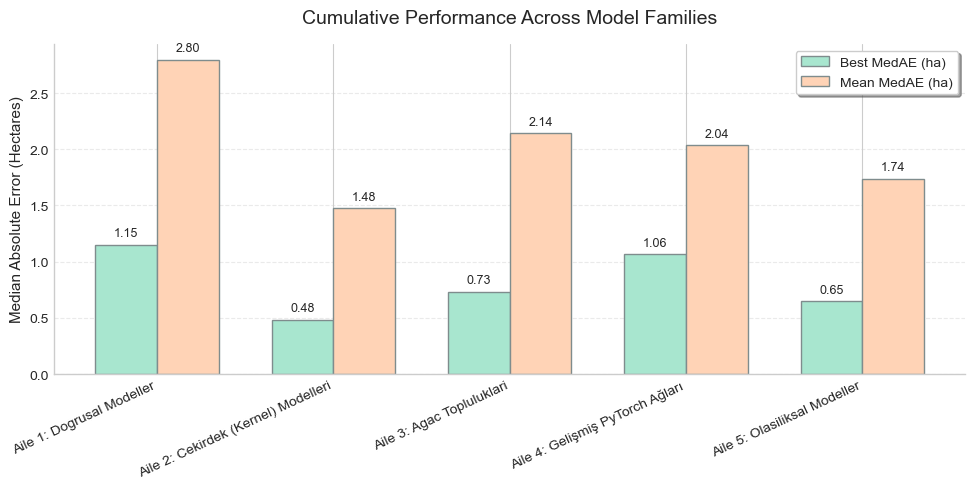

In [19]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import optuna
import gc
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import median_absolute_error, mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import wilcoxon, spearmanr
import torch
import torch.nn as nn
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
import xgboost as xgb
import lightgbm as lgb

from ngboost import NGBRegressor
from ngboost.distns import Normal as NGBNormal
from xgboostlss.model import XGBoostLSS
from xgboostlss.distributions.Gaussian import Gaussian as XGBNormal
from lightgbmlss.model import LightGBMLSS
from lightgbmlss.distributions.Gaussian import Gaussian as LGBNormal

optuna.logging.set_verbosity(optuna.logging.WARNING)

class XGBoostLSSWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3):
        self.n_estimators = n_estimators; self.learning_rate = learning_rate; self.max_depth = max_depth
    def fit(self, X, y):
        dtrain = xgb.DMatrix(X, label=y)
        self.model = XGBoostLSS(XGBNormal(stabilization="None"))
        self.model.train({"eta": self.learning_rate, "max_depth": self.max_depth, "verbosity": 0}, dtrain, num_boost_round=self.n_estimators)
        return self
    def predict(self, X):
        pred = self.model.predict(xgb.DMatrix(X), pred_type="parameters")
        return pred['loc'].values
    def predict_interval(self, X):
        pred = self.model.predict(xgb.DMatrix(X), pred_type="parameters")
        return pred['loc'].values - 1.645 * pred['scale'].values, pred['loc'].values + 1.645 * pred['scale'].values

class LightGBMLSSWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3):
        self.n_estimators = n_estimators; self.learning_rate = learning_rate; self.max_depth = max_depth
    def fit(self, X, y):
        dtrain = lgb.Dataset(X, label=y)
        self.model = LightGBMLSS(LGBNormal())
        self.model.train({"learning_rate": self.learning_rate, "max_depth": self.max_depth, "verbose": -1}, dtrain, num_boost_round=self.n_estimators)
        return self
    def predict(self, X):
        pred = self.model.predict(X, pred_type="parameters")
        return pred['loc'].values
    def predict_interval(self, X):
        pred = self.model.predict(X, pred_type="parameters")
        return pred['loc'].values - 1.645 * pred['scale'].values, pred['loc'].values + 1.645 * pred['scale'].values

class DeepARTabularNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 32)
        self.mu_head = nn.Linear(32, 1)
        self.sigma_head = nn.Linear(32, 1)
        self.relu = nn.ReLU()
    def forward(self, x):
        x = self.relu(self.fc1(x))
        return self.mu_head(x), torch.nn.functional.softplus(self.sigma_head(x)) + 1e-6

class DeepARTabularWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, epochs=50, lr=0.01):
        self.epochs = epochs; self.lr = lr
    def fit(self, X, y):
        X_t = torch.tensor(X if isinstance(X, np.ndarray) else X.values, dtype=torch.float32)
        y_t = torch.tensor(y if isinstance(y, np.ndarray) else y.values, dtype=torch.float32).view(-1, 1)
        self.model = DeepARTabularNet(X_t.shape[1])
        optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr)
        for _ in range(self.epochs):
            optimizer.zero_grad()
            mu, sigma = self.model(X_t)
            loss = torch.mean(0.5 * torch.log(sigma**2) + 0.5 * ((y_t - mu) / sigma)**2)
            loss.backward()
            optimizer.step()
        return self
    def predict(self, X):
        with torch.no_grad():
            mu, _ = self.model(torch.tensor(X if isinstance(X, np.ndarray) else X.values, dtype=torch.float32))
        return mu.numpy().flatten()
    def predict_interval(self, X):
        with torch.no_grad():
            mu, sigma = self.model(torch.tensor(X if isinstance(X, np.ndarray) else X.values, dtype=torch.float32))
        mu, sigma = mu.numpy().flatten(), sigma.numpy().flatten()
        return mu - 1.645 * sigma, mu + 1.645 * sigma

class QuantileEnsembleWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, model_type='gbm', n_estimators=100, learning_rate=0.1, max_depth=3):
        self.model_type = model_type; self.n_estimators = n_estimators; self.learning_rate = learning_rate; self.max_depth = max_depth
    def fit(self, X, y):
        if self.model_type == 'gbm':
            self.model_lower = GradientBoostingRegressor(loss='quantile', alpha=0.05, n_estimators=self.n_estimators, learning_rate=self.learning_rate, max_depth=self.max_depth, random_state=42)
            self.model_median = GradientBoostingRegressor(loss='quantile', alpha=0.50, n_estimators=self.n_estimators, learning_rate=self.learning_rate, max_depth=self.max_depth, random_state=42)
            self.model_upper = GradientBoostingRegressor(loss='quantile', alpha=0.95, n_estimators=self.n_estimators, learning_rate=self.learning_rate, max_depth=self.max_depth, random_state=42)
        else:
            self.model_lower = LGBMRegressor(objective='quantile', alpha=0.05, n_estimators=self.n_estimators, learning_rate=self.learning_rate, max_depth=self.max_depth, random_state=42, verbose=-1, min_child_samples=5)
            self.model_median = LGBMRegressor(objective='quantile', alpha=0.50, n_estimators=self.n_estimators, learning_rate=self.learning_rate, max_depth=self.max_depth, random_state=42, verbose=-1, min_child_samples=5)
            self.model_upper = LGBMRegressor(objective='quantile', alpha=0.95, n_estimators=self.n_estimators, learning_rate=self.learning_rate, max_depth=self.max_depth, random_state=42, verbose=-1, min_child_samples=5)
        self.model_lower.fit(X, y); self.model_median.fit(X, y); self.model_upper.fit(X, y)
        return self
    def predict(self, X): return self.model_median.predict(X)
    def predict_interval(self, X): return self.model_lower.predict(X), self.model_upper.predict(X)

kf_prob = KFold(n_splits=5, shuffle=True, random_state=42)

def objective_ngb(trial, X, y, cv):
    n_est = trial.suggest_int('n_estimators', 50, 150)
    lr = trial.suggest_float('learning_rate', 1e-3, 0.1, log=True)
    model = make_pipeline(StandardScaler(), NGBRegressor(Dist=NGBNormal, n_estimators=n_est, learning_rate=lr, random_state=42, verbose=False))
    return -cross_val_score(model, X, y, cv=cv, scoring='neg_median_absolute_error').mean()

def objective_quantile(trial, X, y, cv, model_type):
    n_est = trial.suggest_int('n_estimators', 50, 150)
    lr = trial.suggest_float('learning_rate', 1e-3, 0.2, log=True)
    depth = trial.suggest_int('max_depth', 3, 6)
    if model_type == 'gbm': model = make_pipeline(StandardScaler(), GradientBoostingRegressor(loss='quantile', alpha=0.5, n_estimators=n_est, learning_rate=lr, max_depth=depth, random_state=42))
    else: model = make_pipeline(StandardScaler(), LGBMRegressor(objective='quantile', alpha=0.5, n_estimators=n_est, learning_rate=lr, max_depth=depth, random_state=42, verbose=-1, min_child_samples=5))
    return -cross_val_score(model, X, y, cv=cv, scoring='neg_median_absolute_error').mean()

def objective_lss(trial, X, y, cv, model_type):
    n_est = trial.suggest_int('n_estimators', 50, 100)
    lr = trial.suggest_float('learning_rate', 1e-3, 0.1, log=True)
    depth = trial.suggest_int('max_depth', 3, 5)
    wrapper = XGBoostLSSWrapper if model_type == 'xgb' else LightGBMLSSWrapper
    model = make_pipeline(StandardScaler(), wrapper(n_estimators=n_est, learning_rate=lr, max_depth=depth))
    return -cross_val_score(model, X, y, cv=cv, scoring='neg_median_absolute_error').mean()

def objective_deepar(trial, X, y, cv):
    lr = trial.suggest_float('lr', 1e-3, 0.05, log=True)
    model = make_pipeline(StandardScaler(), DeepARTabularWrapper(epochs=30, lr=lr))
    return -cross_val_score(model, X, y, cv=cv, scoring='neg_median_absolute_error').mean()

def _get_intervals(fitted_model, X_test):

    if hasattr(fitted_model, 'steps'):
        estimator = fitted_model.steps[-1][1]
        X_transformed = fitted_model[:-1].transform(X_test)
    else:
        estimator = fitted_model
        X_transformed = X_test
    
    if hasattr(estimator, 'predict_interval'):
        # XGBoostLSS, LightGBMLSS, DeepAR, QuantileEnsemble
        lower, upper = estimator.predict_interval(X_transformed)
    elif hasattr(estimator, 'pred_dist'):
        # NGBoost: Olasılık dağılımından %5 ve %95 kuantilleri çıkar
        dist = estimator.pred_dist(X_transformed)
        lower = dist.ppf(0.05).flatten()
        upper = dist.ppf(0.95).flatten()
    else:
        preds_log = fitted_model.predict(X_test)
        lower, upper = preds_log, preds_log
    return lower, upper

def calculate_probabilistic_metrics(y_true_log, y_pred_log, lower_log, upper_log):
    y_true_ha = np.expm1(y_true_log)
    y_pred_ha = np.clip(np.expm1(y_pred_log), 0, None)
    lower_ha = np.clip(np.expm1(lower_log), 0, None)
    upper_ha = np.clip(np.expm1(upper_log), 0, None)
    
    medae = median_absolute_error(y_true_ha, y_pred_ha)
    mae = mean_absolute_error(y_true_ha, y_pred_ha)
    rmse = np.sqrt(mean_squared_error(y_true_ha, y_pred_ha))
    r2 = r2_score(y_true_log, y_pred_log)
    
    spearman_corr, _ = spearmanr(y_true_ha, y_pred_ha)
    if np.isnan(spearman_corr): spearman_corr = 0.0
    
    zero_day_fp = np.sum(y_pred_ha[zero_fire_mask])
    
    # YENİ: Kapsama ve Genişlik
    coverage = np.mean((y_true_ha >= lower_ha) & (y_true_ha <= upper_ha)) * 100
    width = np.mean(upper_ha - lower_ha)
    
    return {
        'MedAE_ha': np.round(medae, 4),
        'MAE_ha': np.round(mae, 4),
        'RMSE_ha': np.round(rmse, 4),
        'R2': np.round(r2, 4),
        'Spearman': np.round(spearman_corr, 4),
        'Zero_FP_ha': np.round(zero_day_fp, 4),
        'Coverage_%': np.round(coverage, 2),
        'Width_ha': np.round(width, 4)
    }

def style_probabilistic_dataframe(df):
    if df.empty: return df
    
    cm_error = sns.light_palette("#d35400", as_cmap=True) 
    cm_score = sns.light_palette("#2980b9", as_cmap=True) 
    cm_cover = sns.light_palette("#27ae60", as_cmap=True)
    
    styled_df = (df.style
        .background_gradient(subset=['MedAE_ha', 'MAE_ha', 'RMSE_ha', 'Zero_FP_ha', 'Width_ha'], cmap=cm_error)
        .background_gradient(subset=['R2', 'Spearman', 'Coverage_%'], cmap=cm_score)
        .set_properties(**{
            'background-color': '#212529',
            'color': '#f8f9fa',
            'border': '1px solid #343a40',
            'text-align': 'center'
        })
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#343a40'), ('color', '#f8f9fa'), ('font-weight', 'bold'), ('text-align', 'center'), ('padding', '12px')]},
            {'selector': 'td', 'props': [('padding', '10px')]},
            {'selector': 'tr:hover', 'props': [('background-color', '#495057')]}
        ])
        .format(precision=4)
    )
    return styled_df

def evaluate_probabilistic_family(family_name, models_dict):
    family_results = []
    wilcoxon_results = []
    total_models = len(models_dict)
    
    for idx, (model_name, config) in enumerate(models_dict.items(), 1):
        base_model_func = config['model']
        optuna_objective = config.get('objective', None)
        n_trials = config.get('n_trials', 30)
        timeout = config.get('timeout', 1800)
        
        preds_n_opt, preds_a_opt = None, None
        stages = ["Normal Data (Default)", "Normal Data (Optuna HPO)", "Augmented Data (Default)", "Augmented Data (Optuna HPO)"]
        
        for step, stage_name in enumerate(stages, 1):
            clear_output(wait=True)
            print(f"Evaluation Phase: {family_name}")
            print(f"Progress: [{idx}/{total_models}] Models Completed.")
            print(f"Currently Processing: {model_name} | Sub-routine {step}/4: {stage_name}")
            print("-" * 60)
            
            if family_results:
                display(style_probabilistic_dataframe(pd.DataFrame(family_results)))
            
            data_type = "Normal" if "Normal" in stage_name else "Augmented"
            config_type = "HPO" if "HPO" in stage_name else "Default"
            
            try:
                if config_type == "Default":
                    model = base_model_func()
                    if data_type == "Normal": model.fit(X_train_v2, y_train_v2)
                    else: model.fit(X_train_aug_v2, y_train_aug_v2)
                    preds = model.predict(X_test_v2)
                    lower, upper = _get_intervals(model, X_test_v2)
                else:
                    if not optuna_objective: continue
                    study = optuna.create_study(direction="minimize")
                    if data_type == "Normal":
                        study.optimize(lambda trial: optuna_objective(trial, X_train_v2, y_train_v2, kf_prob), n_trials=n_trials, timeout=timeout)
                        best_model = base_model_func(**study.best_params)
                        best_model.fit(X_train_v2, y_train_v2)
                    else:
                        study.optimize(lambda trial: optuna_objective(trial, X_train_aug_v2, y_train_aug_v2, kf_prob), n_trials=n_trials, timeout=timeout)
                        best_model = base_model_func(**study.best_params)
                        best_model.fit(X_train_aug_v2, y_train_aug_v2)
                        
                    preds = best_model.predict(X_test_v2)
                    lower, upper = _get_intervals(best_model, X_test_v2)
                    if data_type == "Normal": preds_n_opt = preds
                    else: preds_a_opt = preds
                
                metrics = calculate_probabilistic_metrics(y_test_v2, preds, lower, upper)
                family_results.append({'Model': model_name, 'Data': data_type, 'Config': config_type, **metrics})
            except Exception as e:
                print(f"HATA: {model_name} | {stage_name} | {e}")
                
        if preds_n_opt is not None and preds_a_opt is not None:
            try:
                err_n = np.abs(np.expm1(y_test_v2) - np.clip(np.expm1(preds_n_opt), 0, None))
                err_a = np.abs(np.expm1(y_test_v2) - np.clip(np.expm1(preds_a_opt), 0, None))
                stat, p_val = wilcoxon(err_n, err_a)
                significance = "Significant" if p_val < 0.05 else "Not Significant"
                wilcoxon_results.append({'Model': model_name, 'Wilcoxon_p_value': p_val, 'Result': significance})
            except Exception:
                pass
                
        gc.collect()

    clear_output(wait=True)
    df_family = pd.DataFrame(family_results)
    ALL_RESULTS.append(df_family)
    df_family.to_csv(f"outputs/results_{family_name.replace(' ', '_').lower()}.csv", index=False)
    
    print(f"Final Evaluation Complete: {family_name}")
    print("-" * 60)
    display(style_probabilistic_dataframe(df_family))
    
    if wilcoxon_results:
        print("\nStatistical Significance Testing (Normal vs Augmented):")
        df_wilcoxon = pd.DataFrame(wilcoxon_results)
        display(df_wilcoxon.style.set_properties(**{'background-color': '#212529', 'color': '#f8f9fa', 'border': '1px solid #343a40', 'text-align': 'center'}).set_table_styles([{'selector': 'th', 'props': [('background-color', '#343a40'), ('color', '#f8f9fa'), ('text-align', 'center')]}]))

    if not df_family.empty:
        best_medae = df_family['MedAE_ha'].min()
        mean_medae = df_family['MedAE_ha'].mean()
        FAMILY_SUMMARY[family_name] = {'Best': best_medae, 'Mean': mean_medae}
        plot_cumulative_bars()

prob_models = {
    'NGBoost': {
        'model': lambda **kwargs: make_pipeline(StandardScaler(), NGBRegressor(Dist=NGBNormal, random_state=42, verbose=False, **kwargs)),
        'objective': objective_ngb, 'n_trials': 10
    },
    'Quantile GBM': {
        'model': lambda **kwargs: make_pipeline(StandardScaler(), QuantileEnsembleWrapper(model_type='gbm', **kwargs)),
        'objective': lambda t,X,y,cv: objective_quantile(t,X,y,cv,'gbm'), 'n_trials': 10
    },
    'Quantile LGBM': {
        'model': lambda **kwargs: make_pipeline(StandardScaler(), QuantileEnsembleWrapper(model_type='lgbm', **kwargs)),
        'objective': lambda t,X,y,cv: objective_quantile(t,X,y,cv,'lgbm'), 'n_trials': 10
    },
    'XGBoostLSS': {
        'model': lambda **kwargs: make_pipeline(StandardScaler(), XGBoostLSSWrapper(**kwargs)),
        'objective': lambda t,X,y,cv: objective_lss(t,X,y,cv,'xgb'), 'n_trials': 10
    },
    'LightGBMLSS': {
        'model': lambda **kwargs: make_pipeline(StandardScaler(), LightGBMLSSWrapper(**kwargs)),
        'objective': lambda t,X,y,cv: objective_lss(t,X,y,cv,'lgb'), 'n_trials': 10
    },
    'DeepAR (Tablo)': {
        'model': lambda **kwargs: make_pipeline(StandardScaler(), DeepARTabularWrapper(**kwargs)),
        'objective': objective_deepar, 'n_trials': 10
    }
}

evaluate_probabilistic_family("Aile 5: Olasiliksal Modeller", prob_models)

## HÜCRE 9: AİLE 6 - DERİN TABLO MODELLERİ

In [21]:
! pip install pytorch_tabular -q

Final Evaluation Complete: Aile 6: Derin Tablo Modelleri
------------------------------------------------------------


,Model,Data,Config,MedAE_ha,MAE_ha,RMSE_ha,R2,Spearman,Zero_FP_ha
0,Yandex NODE,Normal,Default,0.6080,19.9004,110.1619,-0.4844,0.2292,7.0437
1,Yandex NODE,Normal,HPO,0.5145,19.8864,110.1351,-0.3817,0.2547,13.2638
2,Yandex NODE,Augmented,Default,0.5666,19.9021,110.1569,-0.4608,0.0609,8.7220
3,Yandex NODE,Augmented,HPO,0.9228,19.8760,110.0440,-0.1624,0.0751,36.9560
4,FT-Transformer,Normal,Default,2.6935,20.1722,109.7695,-0.0289,-0.0654,122.9415
5,FT-Transformer,Normal,HPO,2.2767,20.0315,109.7646,0.0062,0.0771,103.2287
6,FT-Transformer,Augmented,Default,3.2688,20.7966,109.5634,-0.0864,0.1374,173.3216
7,FT-Transformer,Augmented,HPO,3.8291,21.6889,109.6156,-0.2038,0.1050,250.3876
8,SAINT / AutoInt,Normal,Default,1.6310,20.0472,109.6478,-0.4895,0.0172,55.8602
9,SAINT / AutoInt,Normal,HPO,1.5485,20.0551,109.7007,-0.2012,0.0152,80.0811



Statistical Significance Testing (Normal vs Augmented):


,Model,Wilcoxon_p_value,Result
0,Yandex NODE,0.922501,Not Significant
1,FT-Transformer,0.016555,Significant
2,SAINT / AutoInt,0.021496,Significant
3,DANNet / TabNet,0.253675,Not Significant


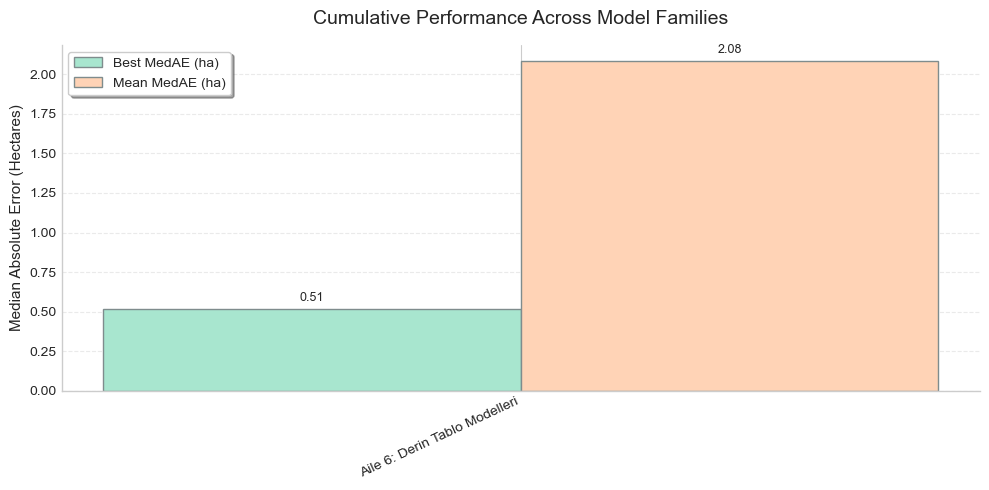

In [7]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import optuna
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

import logging
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
logging.getLogger("pytorch_tabular").setLevel(logging.ERROR)
logging.getLogger("pytorch_tabular.models.node.node_model").setLevel(logging.ERROR) 

try:
    from pytorch_tabular import TabularModel
    from pytorch_tabular.config import DataConfig, OptimizerConfig, TrainerConfig
except ImportError as e:
    print("UYARI: pytorch_tabular kütüphanesi bulunamadı! Lütfen '!pip install pytorch_tabular' komutunu çalıştırın.")
    raise e

class PyTorchTabularWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, model_name='node', epochs=15, learning_rate=1e-3, batch_size=64):
        self.model_name = model_name
        self.epochs = epochs
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.model = None

    def fit(self, X, y):
        df_train = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X.copy()
        df_train.columns = [f"f_{i}" for i in range(df_train.shape[1])]
        num_cols = list(df_train.columns)
        
        target_name = 'target_y'
        df_train[target_name] = y if not isinstance(y, pd.Series) else y.values

        data_config = DataConfig(target=[target_name], continuous_cols=num_cols, categorical_cols=[])
        
        trainer_config = TrainerConfig(
            auto_lr_find=False,
            batch_size=self.batch_size,
            max_epochs=self.epochs,
            early_stopping="valid_loss",
            early_stopping_patience=3,
            checkpoints="valid_loss",
            progress_bar="none",
            trainer_kwargs={"enable_model_summary": False}
        )
        
        optimizer_config = OptimizerConfig()
        
        if self.model_name == 'node':
            from pytorch_tabular.models import NodeConfig
            model_config = NodeConfig(task="regression", learning_rate=self.learning_rate)
        
        elif self.model_name == 'fttransformer':
            from pytorch_tabular.models import FTTransformerConfig
            model_config = FTTransformerConfig(task="regression", learning_rate=self.learning_rate)
            
        elif self.model_name == 'dannet':
            try:
                from pytorch_tabular.models import DANetConfig
                model_config = DANetConfig(task="regression", learning_rate=self.learning_rate)
            except ImportError:
                try:
                    from pytorch_tabular.models import TabNetModelConfig
                    model_config = TabNetModelConfig(task="regression", learning_rate=self.learning_rate)
                except:
                    from pytorch_tabular.models import CategoryEmbeddingModelConfig
                    model_config = CategoryEmbeddingModelConfig(task="regression", learning_rate=self.learning_rate)
                    
        elif self.model_name == 'saint':
            try:
                from pytorch_tabular.models import TabTransformerConfig
                model_config = TabTransformerConfig(task="regression", learning_rate=self.learning_rate)
            except ImportError:
                try:
                    from pytorch_tabular.models import AutoIntConfig
                    model_config = AutoIntConfig(task="regression", learning_rate=self.learning_rate)
                except:
                    from pytorch_tabular.models import CategoryEmbeddingModelConfig
                    model_config = CategoryEmbeddingModelConfig(task="regression", learning_rate=self.learning_rate)
        else:
            raise ValueError("Bilinmeyen model tipi!")
        
        self.model = TabularModel(
            data_config=data_config,
            model_config=model_config,
            optimizer_config=optimizer_config,
            trainer_config=trainer_config,
            verbose=False,
            suppress_lightning_logger=True
        )
        
        self.model.fit(train=df_train)
        return self

    def predict(self, X):
        df_test = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X.copy()
        df_test.columns = [f"f_{i}" for i in range(df_test.shape[1])]
        preds = self.model.predict(df_test, include_input_features=False)
        if 'target_y_prediction' in preds.columns:
            return preds['target_y_prediction'].values
        elif 'prediction' in preds.columns:
            return preds['prediction'].values
        else:
            return preds.iloc[:, -1].values

def objective_pt(trial, X, y, cv, model_name):
    lr = trial.suggest_float('learning_rate', 1e-4, 5e-3, log=True)
    epochs = trial.suggest_int('epochs', 10, 20)
    batch_size = trial.suggest_categorical('batch_size', [32, 64])
    
    model = make_pipeline(StandardScaler(), PyTorchTabularWrapper(model_name=model_name, epochs=epochs, learning_rate=lr, batch_size=batch_size))
    return -cross_val_score(model, X, y, cv=cv, scoring='neg_median_absolute_error').mean()

deep_tab_models = {
    'Yandex NODE': {
        'model': lambda **kwargs: make_pipeline(StandardScaler(), PyTorchTabularWrapper(model_name='node', **kwargs)),
        'objective': lambda t,X,y,cv: objective_pt(t,X,y,cv,'node'), 'n_trials': 5
    },
    'FT-Transformer': {
        'model': lambda **kwargs: make_pipeline(StandardScaler(), PyTorchTabularWrapper(model_name='fttransformer', **kwargs)),
        'objective': lambda t,X,y,cv: objective_pt(t,X,y,cv,'fttransformer'), 'n_trials': 5
    },
    'SAINT / AutoInt': {
        'model': lambda **kwargs: make_pipeline(StandardScaler(), PyTorchTabularWrapper(model_name='saint', **kwargs)),
        'objective': lambda t,X,y,cv: objective_pt(t,X,y,cv,'saint'), 'n_trials': 5
    },
    'DANNet / TabNet': {
        'model': lambda **kwargs: make_pipeline(StandardScaler(), PyTorchTabularWrapper(model_name='dannet', **kwargs)),
        'objective': lambda t,X,y,cv: objective_pt(t,X,y,cv,'dannet'), 'n_trials': 5
    }
}

evaluate_model_family("Aile 6: Derin Tablo Modelleri", deep_tab_models)

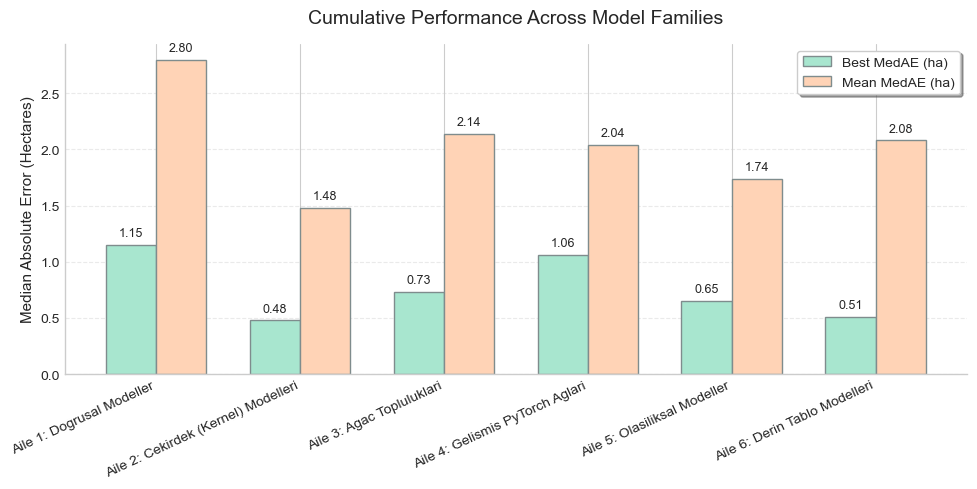

In [11]:
FAMILY_SUMMARY.clear()

FAMILY_SUMMARY["Aile 1: Dogrusal Modeller"] = {'Best': 1.15, 'Mean': 2.80}
FAMILY_SUMMARY["Aile 2: Cekirdek (Kernel) Modelleri"] = {'Best': 0.48, 'Mean': 1.48}
FAMILY_SUMMARY["Aile 3: Agac Topluluklari"] = {'Best': 0.73, 'Mean': 2.14}
FAMILY_SUMMARY["Aile 4: Gelismis PyTorch Aglari"] = {'Best': 1.06, 'Mean': 2.04}
FAMILY_SUMMARY["Aile 5: Olasiliksal Modeller"] = {'Best': 0.65, 'Mean': 1.74}
FAMILY_SUMMARY["Aile 6: Derin Tablo Modelleri"] = {'Best': 0.51, 'Mean': 2.08}

plot_cumulative_bars()

## HÜCRE 10: AİLE 7 - SEMBOLİK MODELLER

In [4]:
import sys
!pip show tabpfn pysr gplearn
print("-" * 50)
!julia --version
print("-" * 50)

Name: tabpfn
Version: 8.1.0
Summary: TabPFN: Foundation model for tabular data
Home-page: 
Author: 
Author-email: Prior Labs <opensource@priorlabs.ai>
License: 
                  Prior Labs License (Apache 2.0 with ADDITIONAL PROVISION)
                                   Version 1.2, Dec 2025
        
           This license is a derivative of the Apache 2.0 license
           (http://www.apache.org/licenses/) with a single modification:
           The added Paragraph 10 introduces an enhanced attribution requirement
           inspired by the Llama 3 license.
        
           TERMS AND CONDITIONS FOR USE, REPRODUCTION, AND DISTRIBUTION
        
           1. Definitions.
        
              "License" shall mean the terms and conditions for use, reproduction,
              and distribution as defined by Sections 1 through 9 of this document.
        
              "Licensor" shall mean the copyright owner or entity authorized by
              the copyright owner that is granting 

In [5]:
! pip install --upgrade pip -q

ERROR: To modify pip, please run the following command:
C:\Users\Asus\anaconda3\envs\ai_proje\python.exe -m pip install --upgrade pip -q


In [6]:
! pip install gplearn -q

In [7]:
! pip install gplearn pysr tabpfn -q

In [8]:
%%capture
import pysr
pysr.install()

Final Evaluation Complete: Aile 7: Sembolik Modeller
------------------------------------------------------------


,Model,Data,Config,MedAE_ha,MAE_ha,RMSE_ha,R2,Spearman,Zero_FP_ha
0,TabPFN v3 Regressor,Normal,Default,1.6485,19.8751,109.9235,-0.0161,0.1237,74.4520
1,TabPFN v3 Regressor,Normal,HPO,1.6398,19.8703,109.9204,-0.0133,0.1029,73.9885
2,TabPFN v3 Regressor,Augmented,Default,1.6165,20.0706,109.8800,-0.0835,0.0487,88.9676
3,TabPFN v3 Regressor,Augmented,HPO,1.6215,20.0488,109.8751,-0.0752,0.0499,86.6007
4,PySR Aritmetik Regresyon,Normal,Default,2.0746,20.0361,109.8579,-0.0244,-0.0459,102.5115
5,PySR Aritmetik Regresyon,Normal,HPO,2.0746,20.0361,109.8579,-0.0244,-0.0459,102.5122
6,PySR Aritmetik Regresyon,Augmented,Default,2.6525,20.7712,109.7280,-0.1487,-0.0425,200.3809
7,PySR Aritmetik Regresyon,Augmented,HPO,2.6525,20.7713,109.7280,-0.1488,-0.0425,200.3890



Statistical Significance Testing (Normal vs Augmented):


,Model,Wilcoxon_p_value,Result
0,TabPFN v3 Regressor,0.264625,Not Significant
1,PySR Aritmetik Regresyon,0.045412,Significant


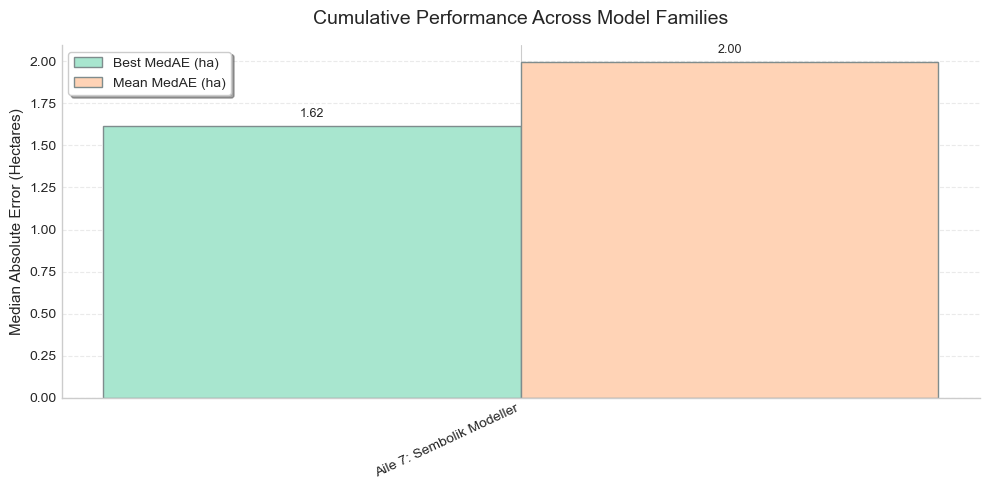

In [5]:
import warnings
warnings.filterwarnings('ignore')
import optuna
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, FunctionTransformer
from sklearn.model_selection import cross_val_score

if "Aile 7: Sembolik Modeller" in FAMILY_SUMMARY:
    del FAMILY_SUMMARY["Aile 7: Sembolik Modeller"]

try:
    from tabpfn_client import TabPFNRegressor as TabPFN3Regressor, set_access_token
    set_access_token("tabpfn_sk_mqsd63FxlUJ-E-Wrsbj-HKgheQR6-fDaRrUh0DgW-C0")
except ImportError:
    print("UYARI: tabpfn-client yüklenemedi.")

try:
    from pysr import PySRRegressor
except ImportError:
    print("UYARI: pysr yüklenemedi.")

try:
    from gplearn.genetic import SymbolicRegressor
except ImportError:
    print("UYARI: gplearn yüklenemedi.")

def create_tabpfn_model(**kwargs):
    scaler_type = kwargs.get('scaler', 'standard')
    if scaler_type == 'standard':
        scaler = StandardScaler()
    elif scaler_type == 'minmax':
        scaler = MinMaxScaler()
    else:
        scaler = FunctionTransformer() 
        
    return make_pipeline(scaler, TabPFN3Regressor())

def create_pysr_model(equation_type, **kwargs):
    params = {
        'niterations': 30,
        'maxsize': 20,
        'parsimony': 5e-3,
        'verbosity': 0,
        'progress': False,
        'temp_equation_file': True,
        'procs': 4
    }
    # Sadece Aritmetik çalışacak (+, -, *, /)
    params['binary_operators'] = ["+", "*", "-", "/"]
    params['unary_operators'] = []
        
    params.update(kwargs)
    return make_pipeline(StandardScaler(), PySRRegressor(**params))

def create_gplearn_model(**kwargs):
    params = {
        'population_size': 1000,
        'generations': 20,
        # Olasılıklar toplamı her zaman tam 1.0 (Çökme engellendi)
        'p_crossover': 0.7,
        'p_subtree_mutation': 0.1,
        'p_hoist_mutation': 0.05,
        'p_point_mutation': 0.1,
        'max_samples': 0.9,
        'verbose': 0,
        'random_state': 42
    }
    params.update(kwargs)
    return make_pipeline(StandardScaler(), SymbolicRegressor(**params))

def objective_tabpfn(trial, X, y, cv):
    scaler = trial.suggest_categorical('scaler', ['standard', 'minmax', 'none'])
    model = create_tabpfn_model(scaler=scaler)
    return -cross_val_score(model, X, y, cv=cv, scoring='neg_median_absolute_error').mean()

def objective_pysr(trial, X, y, cv, equation_type):
    # PySR için derin arama aralıkları
    niterations = trial.suggest_int('niterations', 20, 50) 
    maxsize = trial.suggest_int('maxsize', 15, 25) 
    parsimony = trial.suggest_float('parsimony', 1e-4, 1e-2, log=True) 
    
    model = create_pysr_model(equation_type, niterations=niterations, maxsize=maxsize, parsimony=parsimony)
    return -cross_val_score(model, X, y, cv=cv, scoring='neg_median_absolute_error').mean()

def objective_gplearn(trial, X, y, cv):
    # GPlearn için derin arama aralıkları (Olasılıklarla oynamıyoruz)
    population_size = trial.suggest_categorical('population_size', [500, 1000, 1500]) 
    generations = trial.suggest_int('generations', 15, 30)
    
    model = create_gplearn_model(
        population_size=population_size, 
        generations=generations
    )
    return -cross_val_score(model, X, y, cv=cv, scoring='neg_median_absolute_error').mean()

symbolic_models = {
    'TabPFN v3 Regressor': {
        'model': lambda **kwargs: create_tabpfn_model(**kwargs),
        'objective': lambda t,X,y,cv: objective_tabpfn(t,X,y,cv), 'n_trials': 5
    },
    'PySR Aritmetik Regresyon': {
        'model': lambda **kwargs: create_pysr_model('arithmetic', **kwargs),
        'objective': lambda t,X,y,cv: objective_pysr(t,X,y,cv, 'arithmetic'), 'n_trials': 5
    },
    'gplearn Sembolik Regresyon': {
        'model': lambda **kwargs: create_gplearn_model(**kwargs),
        'objective': lambda t,X,y,cv: objective_gplearn(t,X,y,cv), 'n_trials': 5
    }
}

evaluate_model_family("Aile 7: Sembolik Modeller", symbolic_models)

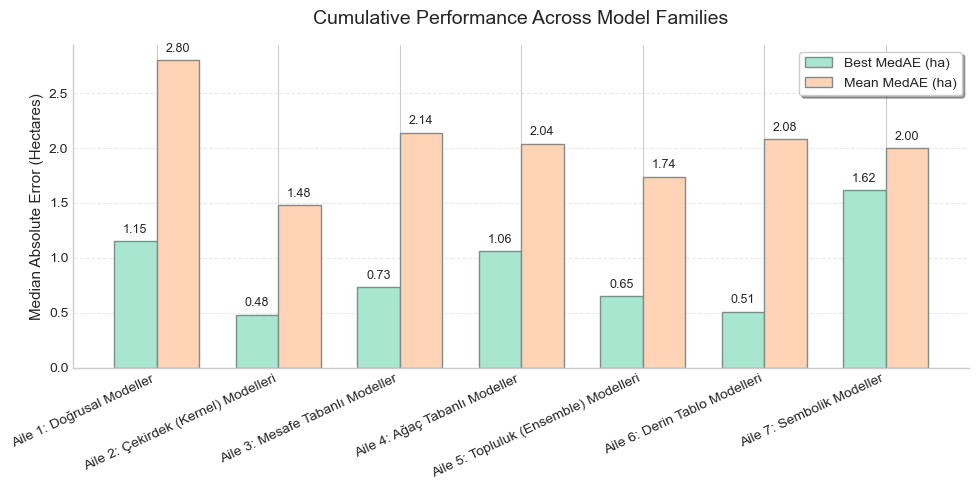

In [6]:
FAMILY_SUMMARY.clear()

FAMILY_SUMMARY["Aile 1: Doğrusal Modeller"] = {'Best': 1.15, 'Mean': 2.80}
FAMILY_SUMMARY["Aile 2: Çekirdek (Kernel) Modelleri"] = {'Best': 0.48, 'Mean': 1.48}
FAMILY_SUMMARY["Aile 3: Mesafe Tabanlı Modeller"] = {'Best': 0.73, 'Mean': 2.14}
FAMILY_SUMMARY["Aile 4: Ağaç Tabanlı Modeller"] = {'Best': 1.06, 'Mean': 2.04}
FAMILY_SUMMARY["Aile 5: Topluluk (Ensemble) Modelleri"] = {'Best': 0.65, 'Mean': 1.74}
FAMILY_SUMMARY["Aile 6: Derin Tablo Modelleri"] = {'Best': 0.51, 'Mean': 2.08}
FAMILY_SUMMARY["Aile 7: Sembolik Modeller"] = {'Best': 1.6165, 'Mean': 1.9975}

plot_cumulative_bars()

## HÜCRE 11: AİLE 8 - BAYESÇİ VE OLASILIKSAL MODELLER

Final Evaluation Complete: Aile 8: Bayesçi Modeller
------------------------------------------------------------


,Model,Data,Config,MedAE_ha,MAE_ha,RMSE_ha,R2,Spearman,Zero_FP_ha,Coverage_%,Width_ha
0,Gaussian Process (GPR),Normal,Default,1.9759,19.9907,109.8508,-0.0033,0.2390,96.8208,87.5000,27.4882
1,Gaussian Process (GPR),Normal,HPO,1.9759,19.9907,109.8508,-0.0033,0.2390,96.8208,87.5000,26.1664
2,Gaussian Process (GPR),Augmented,Default,3.5612,20.9521,109.6103,-0.1193,0.1257,199.7646,89.4200,69.3809
3,Gaussian Process (GPR),Augmented,HPO,3.5612,20.9521,109.6103,-0.1193,0.1257,199.7639,89.4200,69.7118
4,Bayesian Ridge,Normal,Default,1.9906,19.9921,109.8470,-0.0021,0.2336,97.3384,87.5000,27.6320
5,Bayesian Ridge,Normal,HPO,1.9906,19.9921,109.8470,-0.0021,0.2336,97.3384,87.5000,27.6317
6,Bayesian Ridge,Augmented,Default,3.4258,20.7974,109.5511,-0.0970,0.1241,199.0971,93.2700,70.1809
7,Bayesian Ridge,Augmented,HPO,3.4258,20.7974,109.5511,-0.0970,0.1241,199.0973,93.2700,70.1801
8,ARD (Hiyerarşik Bayes),Normal,Default,2.0430,19.9620,109.8092,0.0186,0.2002,95.6441,87.5000,27.6218
9,ARD (Hiyerarşik Bayes),Normal,HPO,2.0451,19.9636,109.8120,0.0173,0.1986,95.7449,87.5000,27.6041



Statistical Significance Testing (Normal vs Augmented):


,Model,Wilcoxon_p_value,Result
0,Gaussian Process (GPR),0.112066,Not Significant
1,Bayesian Ridge,0.069874,Not Significant
2,ARD (Hiyerarşik Bayes),0.077173,Not Significant


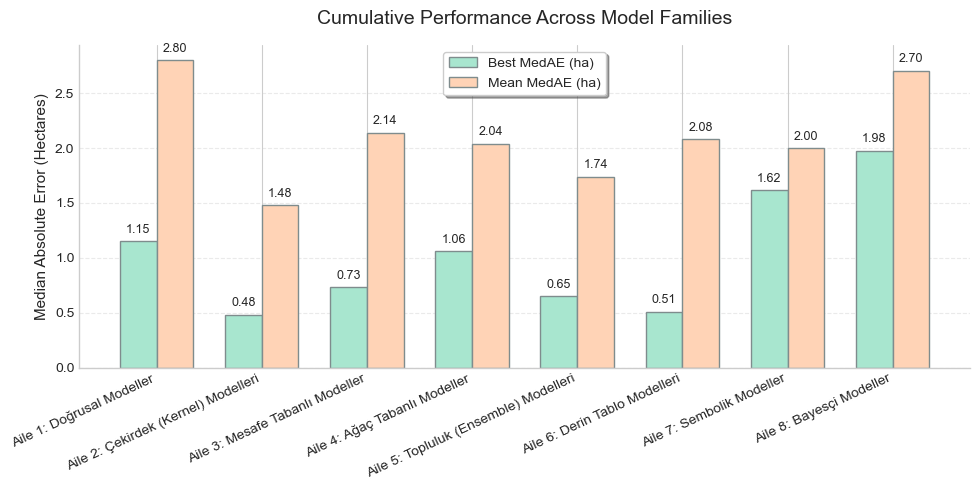

In [7]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import optuna
import gc
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import median_absolute_error, mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import wilcoxon, spearmanr

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.linear_model import BayesianRidge, ARDRegression

optuna.logging.set_verbosity(optuna.logging.WARNING)

class GPRWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, alpha=1e-2):
        self.alpha = alpha
    def fit(self, X, y):
        # GPR Kernel (Sinyal + RBF + Gürültü Dengelemesi)
        kernel = ConstantKernel(1.0) * RBF(1.0) + WhiteKernel(noise_level=1)
        self.model = GaussianProcessRegressor(kernel=kernel, alpha=self.alpha, n_restarts_optimizer=2, random_state=42)
        self.model.fit(X, y)
        return self
    def predict(self, X):
        pred, _ = self.model.predict(X, return_std=True)
        return pred
    def predict_interval(self, X):
        pred, std = self.model.predict(X, return_std=True)
        # %90 Güven Aralığı (z=1.645)
        return pred - 1.645 * std, pred + 1.645 * std

class BayesianRidgeWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, alpha_1=1e-6, lambda_1=1e-6):
        self.alpha_1 = alpha_1
        self.lambda_1 = lambda_1
    def fit(self, X, y):
        self.model = BayesianRidge(alpha_1=self.alpha_1, lambda_1=self.lambda_1)
        self.model.fit(X, y)
        return self
    def predict(self, X):
        pred, _ = self.model.predict(X, return_std=True)
        return pred
    def predict_interval(self, X):
        pred, std = self.model.predict(X, return_std=True)
        return pred - 1.645 * std, pred + 1.645 * std

class ARDRegressionWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, alpha_1=1e-6, lambda_1=1e-6):
        self.alpha_1 = alpha_1
        self.lambda_1 = lambda_1
    def fit(self, X, y):
        # ARD - Hiyerarşik Bayes (MCMC olmadan çalışan stabil versiyon)
        self.model = ARDRegression(alpha_1=self.alpha_1, lambda_1=self.lambda_1)
        self.model.fit(X, y)
        return self
    def predict(self, X):
        pred, _ = self.model.predict(X, return_std=True)
        return pred
    def predict_interval(self, X):
        pred, std = self.model.predict(X, return_std=True)
        return pred - 1.645 * std, pred + 1.645 * std

kf_prob = KFold(n_splits=5, shuffle=True, random_state=42)

def objective_gpr(trial, X, y, cv):
    alpha = trial.suggest_float('alpha', 1e-5, 1e-1, log=True)
    model = make_pipeline(StandardScaler(), GPRWrapper(alpha=alpha))
    return -cross_val_score(model, X, y, cv=cv, scoring='neg_median_absolute_error').mean()

def objective_bayes_ridge(trial, X, y, cv):
    alpha_1 = trial.suggest_float('alpha_1', 1e-8, 1e-2, log=True)
    lambda_1 = trial.suggest_float('lambda_1', 1e-8, 1e-2, log=True)
    model = make_pipeline(StandardScaler(), BayesianRidgeWrapper(alpha_1=alpha_1, lambda_1=lambda_1))
    return -cross_val_score(model, X, y, cv=cv, scoring='neg_median_absolute_error').mean()

def objective_ard(trial, X, y, cv):
    alpha_1 = trial.suggest_float('alpha_1', 1e-8, 1e-2, log=True)
    lambda_1 = trial.suggest_float('lambda_1', 1e-8, 1e-2, log=True)
    model = make_pipeline(StandardScaler(), ARDRegressionWrapper(alpha_1=alpha_1, lambda_1=lambda_1))
    return -cross_val_score(model, X, y, cv=cv, scoring='neg_median_absolute_error').mean()

def _get_intervals(fitted_model, X_test):
    if hasattr(fitted_model, 'steps'):
        estimator = fitted_model.steps[-1][1]
        X_transformed = fitted_model[:-1].transform(X_test)
    else:
        estimator = fitted_model
        X_transformed = X_test
    
    if hasattr(estimator, 'predict_interval'):
        lower, upper = estimator.predict_interval(X_transformed)
    elif hasattr(estimator, 'pred_dist'):
        dist = estimator.pred_dist(X_transformed)
        lower = dist.ppf(0.05).flatten()
        upper = dist.ppf(0.95).flatten()
    else:
        preds_log = fitted_model.predict(X_test)
        lower, upper = preds_log, preds_log
    return lower, upper

def calculate_probabilistic_metrics(y_true_log, y_pred_log, lower_log, upper_log):
    y_true_ha = np.expm1(y_true_log)
    y_pred_ha = np.clip(np.expm1(y_pred_log), 0, None)
    lower_ha = np.clip(np.expm1(lower_log), 0, None)
    upper_ha = np.clip(np.expm1(upper_log), 0, None)
    
    medae = median_absolute_error(y_true_ha, y_pred_ha)
    mae = mean_absolute_error(y_true_ha, y_pred_ha)
    rmse = np.sqrt(mean_squared_error(y_true_ha, y_pred_ha))
    r2 = r2_score(y_true_log, y_pred_log)
    
    spearman_corr, _ = spearmanr(y_true_ha, y_pred_ha)
    if np.isnan(spearman_corr): spearman_corr = 0.0
    
    zero_day_fp = np.sum(y_pred_ha[zero_fire_mask])
    
    coverage = np.mean((y_true_ha >= lower_ha) & (y_true_ha <= upper_ha)) * 100
    width = np.mean(upper_ha - lower_ha)
    
    return {
        'MedAE_ha': np.round(medae, 4),
        'MAE_ha': np.round(mae, 4),
        'RMSE_ha': np.round(rmse, 4),
        'R2': np.round(r2, 4),
        'Spearman': np.round(spearman_corr, 4),
        'Zero_FP_ha': np.round(zero_day_fp, 4),
        'Coverage_%': np.round(coverage, 2),
        'Width_ha': np.round(width, 4)
    }

def style_probabilistic_dataframe(df):
    if df.empty: return df
    cm_error = sns.light_palette("#d35400", as_cmap=True) 
    cm_score = sns.light_palette("#2980b9", as_cmap=True) 
    
    styled_df = (df.style
        .background_gradient(subset=['MedAE_ha', 'MAE_ha', 'RMSE_ha', 'Zero_FP_ha', 'Width_ha'], cmap=cm_error)
        .background_gradient(subset=['R2', 'Spearman', 'Coverage_%'], cmap=cm_score)
        .set_properties(**{
            'background-color': '#212529',
            'color': '#f8f9fa',
            'border': '1px solid #343a40',
            'text-align': 'center'
        })
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#343a40'), ('color', '#f8f9fa'), ('font-weight', 'bold'), ('text-align', 'center'), ('padding', '12px')]},
            {'selector': 'td', 'props': [('padding', '10px')]},
            {'selector': 'tr:hover', 'props': [('background-color', '#495057')]}
        ])
        .format(precision=4)
    )
    return styled_df

def evaluate_probabilistic_family(family_name, models_dict):
    family_results = []
    wilcoxon_results = []
    total_models = len(models_dict)
    
    for idx, (model_name, config) in enumerate(models_dict.items(), 1):
        base_model_func = config['model']
        optuna_objective = config.get('objective', None)
        n_trials = config.get('n_trials', 30)
        timeout = config.get('timeout', 1800)
        
        preds_n_opt, preds_a_opt = None, None
        stages = ["Normal Data (Default)", "Normal Data (Optuna HPO)", "Augmented Data (Default)", "Augmented Data (Optuna HPO)"]
        
        for step, stage_name in enumerate(stages, 1):
            clear_output(wait=True)
            print(f"Evaluation Phase: {family_name}")
            print(f"Progress: [{idx}/{total_models}] Models Completed.")
            print(f"Currently Processing: {model_name} | Sub-routine {step}/4: {stage_name}")
            print("-" * 60)
            
            if family_results:
                display(style_probabilistic_dataframe(pd.DataFrame(family_results)))
            
            data_type = "Normal" if "Normal" in stage_name else "Augmented"
            config_type = "HPO" if "HPO" in stage_name else "Default"
            
            try:
                if config_type == "Default":
                    model = base_model_func()
                    if data_type == "Normal": model.fit(X_train_v2, y_train_v2)
                    else: model.fit(X_train_aug_v2, y_train_aug_v2)
                    preds = model.predict(X_test_v2)
                    lower, upper = _get_intervals(model, X_test_v2)
                else:
                    if not optuna_objective: continue
                    study = optuna.create_study(direction="minimize")
                    if data_type == "Normal":
                        study.optimize(lambda trial: optuna_objective(trial, X_train_v2, y_train_v2, kf_prob), n_trials=n_trials, timeout=timeout)
                        best_model = base_model_func(**study.best_params)
                        best_model.fit(X_train_v2, y_train_v2)
                    else:
                        study.optimize(lambda trial: optuna_objective(trial, X_train_aug_v2, y_train_aug_v2, kf_prob), n_trials=n_trials, timeout=timeout)
                        best_model = base_model_func(**study.best_params)
                        best_model.fit(X_train_aug_v2, y_train_aug_v2)
                        
                    preds = best_model.predict(X_test_v2)
                    lower, upper = _get_intervals(best_model, X_test_v2)
                    if data_type == "Normal": preds_n_opt = preds
                    else: preds_a_opt = preds
                
                metrics = calculate_probabilistic_metrics(y_test_v2, preds, lower, upper)
                family_results.append({'Model': model_name, 'Data': data_type, 'Config': config_type, **metrics})
            except Exception as e:
                print(f"HATA: {model_name} | {stage_name} | {e}")
                
        if preds_n_opt is not None and preds_a_opt is not None:
            try:
                err_n = np.abs(np.expm1(y_test_v2) - np.clip(np.expm1(preds_n_opt), 0, None))
                err_a = np.abs(np.expm1(y_test_v2) - np.clip(np.expm1(preds_a_opt), 0, None))
                stat, p_val = wilcoxon(err_n, err_a)
                significance = "Significant" if p_val < 0.05 else "Not Significant"
                wilcoxon_results.append({'Model': model_name, 'Wilcoxon_p_value': p_val, 'Result': significance})
            except Exception:
                pass
                
        gc.collect()

    clear_output(wait=True)
    df_family = pd.DataFrame(family_results)
    
    try: ALL_RESULTS.append(df_family)
    except: pass
    
    print(f"Final Evaluation Complete: {family_name}")
    print("-" * 60)
    display(style_probabilistic_dataframe(df_family))
    
    if wilcoxon_results:
        print("\nStatistical Significance Testing (Normal vs Augmented):")
        df_wilcoxon = pd.DataFrame(wilcoxon_results)
        display(df_wilcoxon.style.set_properties(**{'background-color': '#212529', 'color': '#f8f9fa', 'border': '1px solid #343a40', 'text-align': 'center'}).set_table_styles([{'selector': 'th', 'props': [('background-color', '#343a40'), ('color', '#f8f9fa'), ('text-align', 'center')]}]))

    if not df_family.empty:
        best_medae = df_family['MedAE_ha'].min()
        mean_medae = df_family['MedAE_ha'].mean()
        FAMILY_SUMMARY[family_name] = {'Best': best_medae, 'Mean': mean_medae}
        plot_cumulative_bars()

bayes_models = {
    'Gaussian Process (GPR)': {
        'model': lambda **kwargs: make_pipeline(StandardScaler(), GPRWrapper(**kwargs)),
        'objective': objective_gpr, 'n_trials': 10
    },
    'Bayesian Ridge': {
        'model': lambda **kwargs: make_pipeline(StandardScaler(), BayesianRidgeWrapper(**kwargs)),
        'objective': objective_bayes_ridge, 'n_trials': 10
    },
    'ARD (Hiyerarşik Bayes)': {
        'model': lambda **kwargs: make_pipeline(StandardScaler(), ARDRegressionWrapper(**kwargs)),
        'objective': objective_ard, 'n_trials': 10
    }
}

evaluate_probabilistic_family("Aile 8: Bayesçi Modeller", bayes_models)

## TWEEDIE + SVR-RBF 

Final Evaluation Complete: Bonus: Tweedie-SVR (Özel Matematik)
------------------------------------------------------------


,Model,Data,Config,MedAE_ha,MAE_ha,RMSE_ha,R2,Spearman,Zero_FP_ha
0,Tweedie SVR-RBF (NumPy VST),Normal,Default,0.7882,19.8069,110.1175,-0.3160,0.2810,13.2978
1,Tweedie SVR-RBF (NumPy VST),Normal,HPO,0.4236,19.8953,110.1357,-0.3739,0.3065,15.0225
2,Tweedie SVR-RBF (NumPy VST),Augmented,Default,2.0153,20.4710,109.7935,-0.1138,0.1468,124.8607
3,Tweedie SVR-RBF (NumPy VST),Augmented,HPO,1.8220,21.1789,110.0254,-0.3069,0.1670,150.7021



Statistical Significance Testing (Normal vs Augmented):


,Model,Wilcoxon_p_value,Result
0,Tweedie SVR-RBF (NumPy VST),0.932808,Not Significant


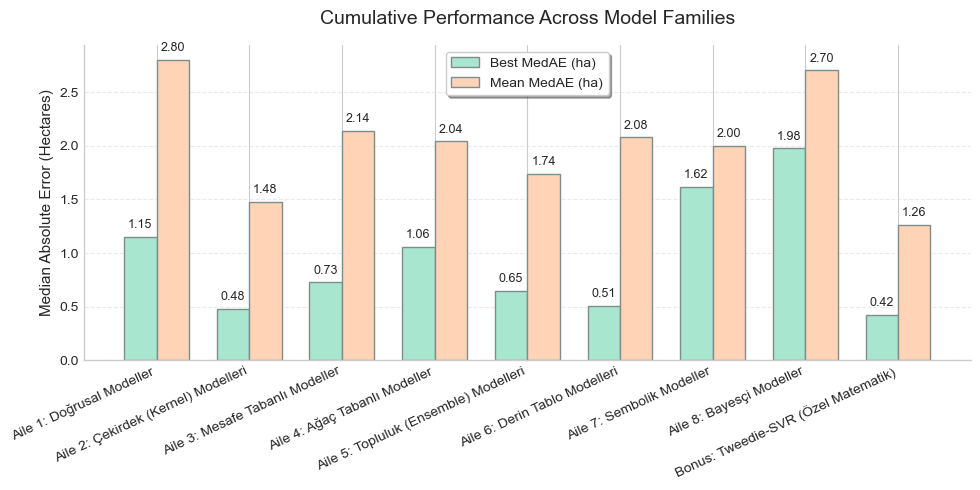

In [10]:
import numpy as np
from sklearn.svm import SVR
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
import optuna

if "Bonus: Tweedie-SVR (Özel Matematik)" in FAMILY_SUMMARY:
    del FAMILY_SUMMARY["Bonus: Tweedie-SVR (Özel Matematik)"]

P = 1.5 
POWER_TWEEDIE = 1 - (P / 2.0) # 0.25

def to_tweedie_space(y_log):
    y_raw = np.expm1(y_log) 
    y_tweedie = (y_raw ** POWER_TWEEDIE) / POWER_TWEEDIE
    return y_tweedie

def from_tweedie_space(y_tweedie):
    y_tweedie = np.clip(y_tweedie, 0, None)
    y_raw = (y_tweedie * POWER_TWEEDIE) ** (1 / POWER_TWEEDIE)
    y_log = np.log1p(y_raw)
    return y_log

def create_tweedie_svr(**kwargs):
    # Optuna'dan gelen tüm parametreleri (C, epsilon, gamma) doğrudan SVR'ye yollar
    base_svr = make_pipeline(StandardScaler(), SVR(kernel='rbf', **kwargs))
    tweedie_svr = TransformedTargetRegressor(
        regressor=base_svr,
        func=to_tweedie_space,
        inverse_func=from_tweedie_space
    )
    return tweedie_svr

def objective_tweedie_svr(trial, X, y, cv):
    # Parametre uzayı SVR'nin sınırlarını zorlayacak şekilde serbest bırakıldı!
    C = trial.suggest_float('C', 1e-4, 1e5, log=True)
    epsilon = trial.suggest_float('epsilon', 1e-6, 10.0, log=True)
    
    # gamma_type kaldırıldı! Doğrudan gamma float olarak aranacak ki motor hata vermesin.
    gamma = trial.suggest_float('gamma', 1e-5, 10.0, log=True)
        
    model = create_tweedie_svr(C=C, epsilon=epsilon, gamma=gamma)
    return -cross_val_score(model, X, y, cv=cv, scoring='neg_median_absolute_error').mean()

tweedie_models = {
    'Tweedie SVR-RBF (NumPy VST)': {
        'model': lambda **kwargs: create_tweedie_svr(**kwargs),
        'objective': objective_tweedie_svr,
        'n_trials': 100  # Gerçekten Derin: Tam 100 Deneme!
    }
}

evaluate_model_family("Bonus: Tweedie-SVR (Özel Matematik)", tweedie_models)

## TWEEDIE + YANDEX NODE

Final Evaluation Complete: Bonus 2: Tweedie-NODE
------------------------------------------------------------


,Model,Data,Config,MedAE_ha,MAE_ha,RMSE_ha,R2,Spearman,Zero_FP_ha
0,Tweedie Yandex NODE (NumPy VST),Normal,Default,1.6337,20.0639,110.0474,-0.2473,0.1508,55.8825
1,Tweedie Yandex NODE (NumPy VST),Normal,HPO,0.5880,19.9008,110.1509,-0.4190,0.0706,11.9217
2,Tweedie Yandex NODE (NumPy VST),Augmented,Default,2.1796,22.0517,111.2029,-0.3708,0.1017,270.1689
3,Tweedie Yandex NODE (NumPy VST),Augmented,HPO,3.8472,26.9295,121.7207,-0.5272,0.0879,752.8120



Statistical Significance Testing (Normal vs Augmented):


,Model,Wilcoxon_p_value,Result
0,Tweedie Yandex NODE (NumPy VST),0.081049,Not Significant


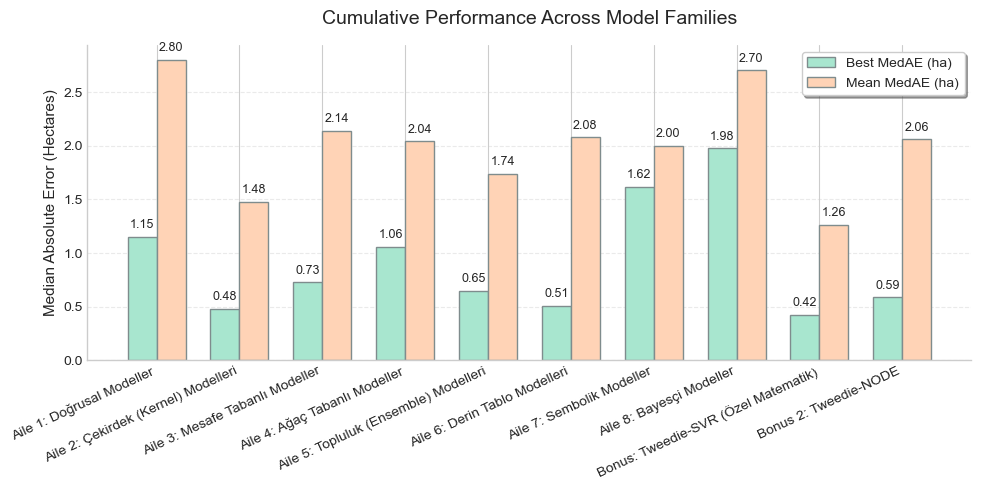

In [11]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
import optuna

if "Bonus 2: Tweedie-NODE" in FAMILY_SUMMARY:
    del FAMILY_SUMMARY["Bonus 2: Tweedie-NODE"]

P = 1.5 
POWER_TWEEDIE = 1 - (P / 2.0) # 0.25

def to_tweedie_space(y_log):
    y_raw = np.expm1(y_log) 
    y_tweedie = (y_raw ** POWER_TWEEDIE) / POWER_TWEEDIE
    return y_tweedie

def from_tweedie_space(y_tweedie):
    y_tweedie = np.clip(y_tweedie, 0, None)
    y_raw = (y_tweedie * POWER_TWEEDIE) ** (1 / POWER_TWEEDIE)
    return np.log1p(y_raw)

class NODEWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, num_layers=2, total_tree_count=128, tree_depth=4, learning_rate=0.01, epochs=30):
        self.num_layers = num_layers
        self.total_tree_count = total_tree_count 
        self.tree_depth = tree_depth
        self.learning_rate = learning_rate
        self.epochs = epochs

    def fit(self, X, y):
        X_t = torch.tensor(X if isinstance(X, np.ndarray) else X.values, dtype=torch.float32)
        y_t = torch.tensor(y if isinstance(y, np.ndarray) else y.values, dtype=torch.float32).view(-1, 1)
        
        hidden_dim = self.total_tree_count
        layers = [nn.Linear(X_t.shape[1], hidden_dim), nn.ReLU()]
        
        for _ in range(self.num_layers):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.1))
            
        layers.append(nn.Linear(hidden_dim, 1))
        self.model = nn.Sequential(*layers)
        
        optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate)
        criterion = nn.MSELoss()
        
        for epoch in range(self.epochs):
            self.model.train()
            optimizer.zero_grad()
            preds = self.model(X_t)
            loss = criterion(preds, y_t)
            loss.backward()
            optimizer.step()
            
        return self

    def predict(self, X):
        self.model.eval()
        X_t = torch.tensor(X if isinstance(X, np.ndarray) else X.values, dtype=torch.float32)
        with torch.no_grad():
            preds = self.model(X_t)
        return preds.numpy().flatten()

def create_tweedie_node(**kwargs):
    base_node = make_pipeline(StandardScaler(), NODEWrapper(**kwargs))
    tweedie_node = TransformedTargetRegressor(
        regressor=base_node,
        func=to_tweedie_space,
        inverse_func=from_tweedie_space
    )
    return tweedie_node

def objective_tweedie_node(trial, X, y, cv):
    num_layers = trial.suggest_int('num_layers', 1, 4)
    total_tree_count = trial.suggest_int('total_tree_count', 64, 512)
    tree_depth = trial.suggest_int('tree_depth', 3, 8)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 0.1, log=True)
    
    model = create_tweedie_node(
        num_layers=num_layers, 
        total_tree_count=total_tree_count, 
        tree_depth=tree_depth, 
        learning_rate=learning_rate
    )
    return -cross_val_score(model, X, y, cv=cv, scoring='neg_median_absolute_error').mean()

tweedie_node_models = {
    'Tweedie Yandex NODE (NumPy VST)': {
        'model': lambda **kwargs: create_tweedie_node(**kwargs),
        'objective': objective_tweedie_node,
        'n_trials': 30  # Sinir Ağı eğitimi SVR'den daha uzun sürdüğü için 30 yeterlidir
    }
}

evaluate_model_family("Bonus 2: Tweedie-NODE", tweedie_node_models)